## Monster–VIDEO Z-band colour transformation

This notebook derives a **VIDEO-specific empirical transformation** from Monster DES-system photometry to the VIRCAM Z band using the three VIDEO DR5 fields:

- CDFS
- ELAIS-S1
- XMM-LSS

The method follows the robust logic developed in `Monster_VIKING_Z.ipynb`, but is adapted to the available VIDEO products.

The fitted quantity is

$$
R_Z(i-z)
=
\frac{F_{\mathrm{Monster,DES},z}}
     {F_{\mathrm{VIDEO},Z}},
$$

with Monster colour

$$
(i-z)_{\mathrm{Monster}}
=
-2.5\log_{10}
\left(
\frac{F_{\mathrm{Monster,DES},i}}
     {F_{\mathrm{Monster,DES},z}}
\right).
$$

The target VIDEO flux can therefore be recovered from the final YAML as

$$
F_{\mathrm{VIDEO},Z}
=
\frac{F_{\mathrm{Monster,DES},z}}
     {R_Z(i-z)}.
$$

Important design choices:

- VIDEO **`Z_FLUX_APER_2`** and `Z_FLUXERR_APER_2` are used, matching the 2-arcsec-diameter aperture adopted for the photometric comparison work.
- VIDEO catalogue fluxes are converted from the AB-zeropoint-30 scale to nJy.
- Monster proper motions are used only for positional matching.
- The effective VIDEO coordinate epoch is measured independently in each field with a 0.5-year coarse scan followed by a 0.1-year refinement.
- Gold matching uses mutual nearest neighbours, Monster-side isolation, and a stricter calibration separation cut.
- High-S/N, clean, star-like sources are used for the colour transformation.
- The three VIDEO fields are **field-balanced** when constructing spline nodes; a field with more stars cannot dominate the relation.
- Robustness is tested with **leave-one-field-out validation**: two VIDEO fields fit the relation and predict the third.
- The final spline is refitted using all three fields only after validation.
- No extrapolation beyond the calibrated colour interval is allowed.

The three input catalogues are field-level DR5 products rather than the individual VISTA tile catalogues used in the VIKING calibration. The statistically independent unit used for balancing and validation is therefore the **VIDEO field**, not the individual detector/tile observation.

### Imports

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import astropy.units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning

from IPython.display import display
from scipy.interpolate import make_interp_spline

### Input catalogues and output paths

The notebook is intended to live in `dmu2/Monster`, so the three VIDEO DR5 catalogues are addressed relative to that directory.

Monster reference-catalogue shards are also required around each of the three VIDEO fields. The resolver below tries several repository-relative locations used by the LSST–VISTA work. If your CDFS or XMM Monster shards are stored elsewhere, edit only `MONSTER_DIR_OVERRIDE`.

In [2]:
VIDEO_DIR = Path("data/VIDEO")

VIDEO_FILES = {
    "CDFS": VIDEO_DIR / "video-cdfs-dr5.fits",
    "ELAIS": VIDEO_DIR / "video-elais-dr5.fits",
    "XMM": VIDEO_DIR / "video-xmm-dr5.fits",
}

MONSTER_BASE_DIR = Path(
    "data/the_monster_20250219"
)

MONSTER_DIRS = {
    "CDFS": MONSTER_BASE_DIR / "CDFS",
    "ELAIS": MONSTER_BASE_DIR / "ELAIS",
    "XMM": MONSTER_BASE_DIR / "XMM",
}

OUTPUT_DIR = Path(
    "data/outputs/Monster_VIDEO_Z"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def monster_fits_files(directory):
    """Return all Monster FITS shards in one field directory."""

    return sorted(
        Path(directory).glob("*.fits")
    )


# Check VIDEO catalogues.
for field, path in VIDEO_FILES.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{field} VIDEO catalogue not found: {path}"
        )


# Check Monster directories and FITS shards.
for field, directory in MONSTER_DIRS.items():

    if not directory.exists():
        raise FileNotFoundError(
            f"{field} Monster directory not found: {directory}"
        )

    files = monster_fits_files(
        directory
    )

    if not files:
        raise FileNotFoundError(
            f"No Monster FITS files found in {directory}"
        )


print("VIDEO catalogues:")

for field, path in VIDEO_FILES.items():
    print(
        f"  {field:5s}: {path}"
    )


print("\nMonster shard directories:")

for field, directory in MONSTER_DIRS.items():

    files = monster_fits_files(
        directory
    )

    print(
        f"  {field:5s}: {directory} "
        f"({len(files)} FITS files)"
    )


print(
    f"\nOutput directory: {OUTPUT_DIR}"
)

VIDEO catalogues:
  CDFS : data/VIDEO/video-cdfs-dr5.fits
  ELAIS: data/VIDEO/video-elais-dr5.fits
  XMM  : data/VIDEO/video-xmm-dr5.fits

Monster shard directories:
  CDFS : data/the_monster_20250219/CDFS (32 FITS files)
  ELAIS: data/the_monster_20250219/ELAIS (24 FITS files)
  XMM  : data/the_monster_20250219/XMM (62 FITS files)

Output directory: data/outputs/Monster_VIDEO_Z


### Calibration configuration

The thresholds remain intentionally close to the conservative VIKING Z-band calibration, but the VIDEO stellar classifier is taken from the deeper Ks detection rather than the Z-band `CLASS_STAR`. This is important because the CDFS DR5 catalogue contains very few usable high-`CLASS_STAR` values in Z, while the Ks classifier is well populated and was already used for the CDFS VIDEO stellar diagnostics.

- mutual-match candidate radius: 0.5 arcsec;
- secure calibration separation: 0.3 arcsec;
- Monster isolation: second-nearest Monster source farther than 1 arcsec;
- minimum S/N: 50 in VIDEO Z and Monster DES i/z;
- VIDEO star classifier: `KS_CLASS_STAR >= 0.90`;
- VIDEO quality flags: `Z_FLAGS == 0` and `KS_FLAGS == 0`;
- safe VIDEO Z magnitude interval: 14–20 AB mag;
- calibrated Monster DES \((i-z)\) interval: 0.0–0.65 mag.

The Ks quantities are used only for source classification/quality selection. The calibrated target photometry remains the VIDEO Z-band `APER_2` flux.


In [3]:
VIDEO_ZP_AB = 30.0

VIDEO_ADU_TO_NJY = (
    VIDEO_ZP_AB
    * u.ABmag
).to_value(
    u.nJy
)

MATCH_RADIUS = (
    0.5
    * u.arcsec
)

CALIBRATION_MATCH_RADIUS_ARCSEC = 0.3

MONSTER_ISOLATION_RADIUS = (
    1.0
    * u.arcsec
)

MINIMUM_SNR = 50.0

VIDEO_STAR_CLASS_MIN = 0.90

MINIMUM_Z_AB = 14.0
MAXIMUM_Z_AB = 20.0

COLOUR_MIN = 0.0
COLOUR_MAX = 0.65

FINAL_NODES = np.linspace(
    COLOUR_MIN,
    COLOUR_MAX,
    10,
)

MINIMUM_STARS_PER_FIELD_BIN = 30
MINIMUM_FIELDS_PER_NODE = 2

STAR_CLIP_THRESHOLD = 4.0
MAXIMUM_CLIP_ITERATIONS = 10

COARSE_EPOCH_GRID = np.arange(
    2000.0,
    2019.0,
    0.5,
)

EPOCH_SCAN_RADIUS = (
    1.0
    * u.arcsec
)

print(
    f"VIDEO APER_2 conversion: "
    f"1 catalogue flux unit = "
    f"{VIDEO_ADU_TO_NJY:.6f} nJy"
)
print(
    f"Final colour nodes: "
    f"{FINAL_NODES[0]:.3f} to "
    f"{FINAL_NODES[-1]:.3f}"
)

VIDEO APER_2 conversion: 1 catalogue flux unit = 3.630781 nJy
Final colour nodes: 0.000 to 0.650


### Helper functions

All array conversions explicitly preserve masked values as NaN. The matching helper implements an exact mutual nearest-neighbour criterion while evaluating the reverse query only for candidate VIDEO counterparts.

Monster `pm_ra` is \(\mu_{\alpha *}\), so the RA propagation divides by \(\cos\delta\).

In [4]:
def float_array(column):
    """Convert an ordinary or masked numerical column to float."""

    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def integer_array(
    column,
    fill_value=-1,
):
    """Convert an ordinary or masked integer column to int64."""

    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column
            ),
            fill_value,
        ),
        dtype=np.int64,
    )


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(
        values
    ) == 0:
        return np.nan

    centre = np.median(
        values
    )

    return float(
        1.4826
        * np.median(
            np.abs(
                values
                - centre
            )
        )
    )


def safe_snr(
    flux,
    flux_error,
):
    """Return flux/error for positive finite measurements."""

    flux = np.asarray(
        flux,
        dtype=float,
    )

    flux_error = np.asarray(
        flux_error,
        dtype=float,
    )

    result = np.full(
        len(
            flux
        ),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(
            flux
        )
        & np.isfinite(
            flux_error
        )
        & (
            flux > 0.0
        )
        & (
            flux_error > 0.0
        )
    )

    result[
        valid
    ] = (
        flux[
            valid
        ]
        / flux_error[
            valid
        ]
    )

    return result


def iterative_nmad_clip(
    values,
    threshold=STAR_CLIP_THRESHOLD,
    maximum_iterations=MAXIMUM_CLIP_ITERATIONS,
):
    """Return points retained after iterative median/NMAD clipping."""

    values = np.asarray(
        values,
        dtype=float,
    )

    keep = np.isfinite(
        values
    )

    for _ in range(
        maximum_iterations
    ):

        retained = values[
            keep
        ]

        if len(
            retained
        ) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = robust_nmad(
            retained
        )

        if (
            not np.isfinite(
                scatter
            )
            or scatter <= 0.0
        ):
            break

        new_keep = (
            np.isfinite(
                values
            )
            & (
                np.abs(
                    values
                    - centre
                )
                <= threshold
                * scatter
            )
        )

        if np.array_equal(
            new_keep,
            keep,
        ):
            break

        keep = new_keep

    return keep


def mutual_nn_match(
    coords_a,
    coords_b,
    radius,
):
    """Return mutual nearest-neighbour matches from A to B."""

    if (
        len(
            coords_a
        ) == 0
        or len(
            coords_b
        ) == 0
    ):
        return (
            np.zeros(
                len(
                    coords_a
                ),
                dtype=bool,
            ),
            np.zeros(
                len(
                    coords_a
                ),
                dtype=int,
            ),
            np.full(
                len(
                    coords_a
                ),
                np.inf,
            )
            * u.arcsec,
        )

    idx_b, sep_ab, _ = (
        match_coordinates_sky(
            coords_a,
            coords_b,
        )
    )

    within = (
        sep_ab
        < radius
    )

    candidate_b = np.unique(
        idx_b[
            within
        ]
    )

    reverse_nearest = {}

    if len(
        candidate_b
    ) > 0:

        idx_a_back, _, _ = (
            match_coordinates_sky(
                coords_b[
                    candidate_b
                ],
                coords_a,
            )
        )

        reverse_nearest = {
            int(
                b_index
            ): int(
                a_index
            )
            for b_index, a_index
            in zip(
                candidate_b,
                idx_a_back,
            )
        }

    mutual = np.fromiter(
        (
            reverse_nearest.get(
                int(
                    b_index
                ),
                -1,
            )
            == a_index
            for a_index, b_index
            in enumerate(
                idx_b
            )
        ),
        dtype=bool,
        count=len(
            idx_b
        ),
    )

    return (
        within
        & mutual,
        idx_b,
        sep_ab,
    )


def isolate_mask(
    coords,
    min_sep=MONSTER_ISOLATION_RADIUS,
):
    """Require the second-nearest Monster source to be farther away."""

    if len(
        coords
    ) < 2:
        return np.ones(
            len(
                coords
            ),
            dtype=bool,
        )

    _, sep2, _ = (
        match_coordinates_sky(
            coords,
            coords,
            nthneighbor=2,
        )
    )

    return (
        sep2
        > min_sep
    )


def propagate_monster_pm_only(
    monster,
    target_mjd,
):
    """Propagate valid Monster coordinates to target MJD using PM only."""

    ra0 = float_array(
        monster[
            "coord_ra"
        ]
    )

    dec0 = float_array(
        monster[
            "coord_dec"
        ]
    )

    epoch = float_array(
        monster[
            "epoch"
        ]
    )

    pmra = float_array(
        monster[
            "pm_ra"
        ]
    )

    pmdec = float_array(
        monster[
            "pm_dec"
        ]
    )

    valid = (
        np.isfinite(
            ra0
        )
        & np.isfinite(
            dec0
        )
        & np.isfinite(
            epoch
        )
        & np.isfinite(
            pmra
        )
        & np.isfinite(
            pmdec
        )
        & (
            np.abs(
                np.cos(
                    dec0
                )
            )
            > 1.0e-10
        )
    )

    original_index = (
        np.flatnonzero(
            valid
        )
    )

    ra0 = ra0[
        valid
    ]
    dec0 = dec0[
        valid
    ]
    epoch = epoch[
        valid
    ]
    pmra = pmra[
        valid
    ]
    pmdec = pmdec[
        valid
    ]

    dt_year = (
        target_mjd
        - epoch
    ) / 365.25

    propagated_ra = (
        ra0
        + (
            pmra
            * dt_year
        )
        / np.cos(
            dec0
        )
    )

    propagated_dec = (
        dec0
        + pmdec
        * dt_year
    )

    propagated_ra = np.mod(
        propagated_ra,
        2.0
        * np.pi,
    )

    valid_propagated = (
        np.isfinite(
            propagated_ra
        )
        & np.isfinite(
            propagated_dec
        )
        & (
            propagated_dec
            >= -0.5
            * np.pi
        )
        & (
            propagated_dec
            <= 0.5
            * np.pi
        )
    )

    coords = SkyCoord(
        ra=propagated_ra[
            valid_propagated
        ]
        * u.rad,
        dec=propagated_dec[
            valid_propagated
        ]
        * u.rad,
        frame="icrs",
    )

    return (
        coords,
        original_index[
            valid_propagated
        ],
    )


def evaluate_spline(
    spline,
    colours,
    minimum_colour,
    maximum_colour,
):
    """Evaluate a spline only inside its calibrated colour interval."""

    colours = np.asarray(
        colours,
        dtype=float,
    )

    result = np.full(
        len(
            colours
        ),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(
            colours
        )
        & (
            colours
            >= minimum_colour
        )
        & (
            colours
            <= maximum_colour
        )
    )

    result[
        valid
    ] = spline(
        colours[
            valid
        ]
    )

    return result

### Load the required VIDEO Z-band columns

The public VIDEO catalogues contain hundreds of columns. Each FITS file is memory-mapped and only the columns needed for astrometry, Z-band photometry, and robust stellar selection are copied into memory.

The notebook requires:

- `RA2000`, `DEC2000`;
- `Z_FLUX_APER_2`, `Z_FLUXERR_APER_2`;
- `Z_MAG_APER_2`, `Z_MAGERR_APER_2`;
- `Z_CLASS_STAR`, `Z_FLAGS` for diagnostics and Z-band quality;
- `KS_MAG_APER_2`, `KS_MAGERR_APER_2`;
- `KS_CLASS_STAR`, `KS_FLAGS` for the common stellar classifier.

The implied Z-band catalogue zeropoint is measured independently in each field as

$$
ZP
=
m_Z
+
2.5\log_{10}(F_Z).
$$

It should be consistent with 30.0 before the flux conversion is used.


In [5]:
VIDEO_REQUIRED_COLUMNS = [
    "RA2000",
    "DEC2000",
    "Z_FLUX_APER_2",
    "Z_FLUXERR_APER_2",
    "Z_MAG_APER_2",
    "Z_MAGERR_APER_2",
    "Z_CLASS_STAR",
    "Z_FLAGS",
    "KS_MAG_APER_2",
    "KS_MAGERR_APER_2",
    "KS_CLASS_STAR",
    "KS_FLAGS",
]


def read_video_minimal(path):
    """Memory-map one VIDEO catalogue and copy only required columns."""

    with fits.open(
        path,
        memmap=True,
    ) as hdul:

        table_hdu = next(
            (
                hdu
                for hdu in hdul
                if isinstance(
                    hdu,
                    fits.BinTableHDU,
                )
                and hdu.data is not None
            ),
            None,
        )

        if table_hdu is None:
            raise RuntimeError(
                f"No binary-table HDU found in {path}"
            )

        available = set(
            table_hdu.columns.names
        )

        missing = [
            name
            for name
            in VIDEO_REQUIRED_COLUMNS
            if name not in available
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing VIDEO columns: "
                + ", ".join(
                    missing
                )
            )

        table = Table(
            {
                name: np.array(
                    table_hdu.data[
                        name
                    ],
                    copy=True,
                )
                for name
                in VIDEO_REQUIRED_COLUMNS
            }
        )

    return table


video_tables = {}

video_audit_records = []

for field, path in VIDEO_FILES.items():

    video = read_video_minimal(
        path
    )

    ra = float_array(
        video[
            "RA2000"
        ]
    )

    dec = float_array(
        video[
            "DEC2000"
        ]
    )

    flux = float_array(
        video[
            "Z_FLUX_APER_2"
        ]
    )

    mag = float_array(
        video[
            "Z_MAG_APER_2"
        ]
    )

    z_class_star = float_array(
        video[
            "Z_CLASS_STAR"
        ]
    )

    z_flags = integer_array(
        video[
            "Z_FLAGS"
        ],
        fill_value=999,
    )

    ks_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    finite_coord = (
        np.isfinite(
            ra
        )
        & np.isfinite(
            dec
        )
    )

    video = video[
        finite_coord
    ]

    flux = flux[
        finite_coord
    ]

    mag = mag[
        finite_coord
    ]

    z_class_star = z_class_star[
        finite_coord
    ]

    z_flags = z_flags[
        finite_coord
    ]

    ks_class_star = ks_class_star[
        finite_coord
    ]

    ks_flags = ks_flags[
        finite_coord
    ]

    good_zp = (
        np.isfinite(
            flux
        )
        & np.isfinite(
            mag
        )
        & (
            flux > 0.0
        )
    )

    implied_zp = (
        mag[
            good_zp
        ]
        + 2.5
        * np.log10(
            flux[
                good_zp
            ]
        )
    )

    zp_median = float(
        np.median(
            implied_zp
        )
    )

    zp_nmad = robust_nmad(
        implied_zp
    )

    if not np.isclose(
        zp_median,
        VIDEO_ZP_AB,
        atol=1.0e-3,
    ):
        raise RuntimeError(
            f"{field}: implied VIDEO Z zeropoint "
            f"{zp_median:.6f} is inconsistent with "
            f"{VIDEO_ZP_AB:.1f}."
        )

    video_tables[
        field
    ] = video

    video_audit_records.append(
        {
            "field":
                field,
            "rows":
                len(
                    video
                ),
            "ra_min_deg":
                float(
                    np.nanmin(
                        float_array(
                            video[
                                "RA2000"
                            ]
                        )
                    )
                ),
            "ra_max_deg":
                float(
                    np.nanmax(
                        float_array(
                            video[
                                "RA2000"
                            ]
                        )
                    )
                ),
            "dec_min_deg":
                float(
                    np.nanmin(
                        float_array(
                            video[
                                "DEC2000"
                            ]
                        )
                    )
                ),
            "dec_max_deg":
                float(
                    np.nanmax(
                        float_array(
                            video[
                                "DEC2000"
                            ]
                        )
                    )
                ),
            "median_implied_zp":
                zp_median,
            "zp_nmad":
                zp_nmad,
            "fraction_z_flags_zero":
                float(
                    np.mean(
                        z_flags == 0
                    )
                ),
            "fraction_ks_flags_zero":
                float(
                    np.mean(
                        ks_flags == 0
                    )
                ),
            "fraction_z_classstar_gt_0p9":
                float(
                    np.mean(
                        np.isfinite(
                            z_class_star
                        )
                        & (
                            z_class_star
                            >= VIDEO_STAR_CLASS_MIN
                        )
                    )
                ),
            "fraction_ks_classstar_gt_0p9":
                float(
                    np.mean(
                        np.isfinite(
                            ks_class_star
                        )
                        & (
                            ks_class_star
                            >= VIDEO_STAR_CLASS_MIN
                        )
                    )
                ),
        }
    )

video_audit = pd.DataFrame(
    video_audit_records
)

display(
    video_audit
)


,field,rows,ra_min_deg,ra_max_deg,dec_min_deg,dec_max_deg,median_implied_zp,zp_nmad,fraction_z_flags_zero,fraction_ks_flags_zero,fraction_z_classstar_gt_0p9,fraction_ks_classstar_gt_0p9
0,CDFS,1138485,51.680846,54.626777,-29.239209,-26.962220,30.0,7.069957e-07,0.317561,0.868168,0.000244,0.035842
1,ELAIS,842337,8.374665,10.533339,-45.149690,-42.851887,30.0,7.073032e-07,0.843002,0.843236,0.052243,0.049912
2,XMM,1279857,33.813489,37.187919,-5.641906,-3.985394,30.0,7.072876e-07,0.628613,0.848832,0.032449,0.039183


### Inspect VIDEO stellar-classification behaviour

This diagnostic explicitly compares the Z-band and Ks-band `CLASS_STAR` behaviour in the same safe Z magnitude interval. The final calibration uses the Ks classifier because it provides a much more uniform stellar-selection quantity across the three VIDEO fields.

For the Ks-based rows, the source must also have `KS_FLAGS == 0`; in both cases the Z measurement itself must have `Z_FLAGS == 0`.


In [6]:
classification_records = []

for field, video in video_tables.items():

    z_mag = float_array(
        video[
            "Z_MAG_APER_2"
        ]
    )

    z_class_star = float_array(
        video[
            "Z_CLASS_STAR"
        ]
    )

    z_flags = integer_array(
        video[
            "Z_FLAGS"
        ],
        fill_value=999,
    )

    ks_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    safe_z = (
        np.isfinite(
            z_mag
        )
        & (
            z_flags == 0
        )
        & (
            z_mag > MINIMUM_Z_AB
        )
        & (
            z_mag < MAXIMUM_Z_AB
        )
    )

    classifier_specs = {
        "Z": (
            z_class_star,
            np.ones(
                len(
                    video
                ),
                dtype=bool,
            ),
        ),
        "Ks": (
            ks_class_star,
            ks_flags == 0,
        ),
    }

    for classifier_band, (
        class_star,
        extra_quality,
    ) in classifier_specs.items():

        base = (
            safe_z
            & extra_quality
            & np.isfinite(
                class_star
            )
        )

        for threshold in [
            0.70,
            0.90,
            0.95,
        ]:

            classification_records.append(
                {
                    "field":
                        field,
                    "classifier_band":
                        classifier_band,
                    "class_star_min":
                        threshold,
                    "number":
                        int(
                            np.count_nonzero(
                                base
                                & (
                                    class_star
                                    >= threshold
                                )
                            )
                        ),
                }
            )

classification_table = pd.DataFrame(
    classification_records
)

display(
    classification_table
)


,field,classifier_band,class_star_min,number
0,CDFS,Z,0.70,604
1,CDFS,Z,0.90,103
2,CDFS,Z,0.95,56
3,CDFS,Ks,0.70,2953
4,CDFS,Ks,0.90,2913
5,CDFS,Ks,0.95,2824
6,ELAIS,Z,0.70,5639
7,ELAIS,Z,0.90,5624
8,ELAIS,Z,0.95,5611
9,ELAIS,Ks,0.70,5730


### Load the Monster astrometric and DES i/z fields

Only the columns required for proper-motion matching and the Z colour transformation are retained.

The input Monster schema is never modified in this notebook.

In [7]:
MONSTER_REQUIRED_COLUMNS = [
    "id",
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_i_flux",
    "monster_DES_i_fluxErr",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
]


def read_monster_field(
    directory,
):
    """Read and combine the required columns from one field's HTM shards."""

    paths = monster_fits_files(
        directory
    )

    if not paths:
        raise FileNotFoundError(
            f"No Monster FITS files found in {directory}"
        )

    tables = []

    for path in paths:

        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore",
                AstropyWarning,
            )

            table = Table.read(
                path
            )

        missing = [
            name
            for name
            in MONSTER_REQUIRED_COLUMNS
            if name
            not in table.colnames
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing Monster columns: "
                + ", ".join(
                    missing
                )
            )

        tables.append(
            table[
                MONSTER_REQUIRED_COLUMNS
            ].copy(
                copy_data=True
            )
        )

    combined = vstack(
        tables,
        join_type="exact",
        metadata_conflicts="silent",
    )

    ids = integer_array(
        combined[
            "id"
        ]
    )

    if len(
        np.unique(
            ids
        )
    ) != len(
        ids
    ):
        raise RuntimeError(
            f"Duplicate Monster IDs found after combining {directory}."
        )

    return combined


monster_tables = {}

monster_audit_records = []

for field, directory in MONSTER_DIRS.items():

    monster = read_monster_field(
        directory
    )

    monster_tables[
        field
    ] = monster

    monster_audit_records.append(
        {
            "field":
                field,
            "rows":
                len(
                    monster
                ),
            "n_shards":
                len(
                    monster_fits_files(
                        directory
                    )
                ),
            "median_epoch_mjd":
                float(
                    np.nanmedian(
                        float_array(
                            monster[
                                "epoch"
                            ]
                        )
                    )
                ),
            "finite_pm_fraction":
                float(
                    np.mean(
                        np.isfinite(
                            float_array(
                                monster[
                                    "pm_ra"
                                ]
                            )
                        )
                        & np.isfinite(
                            float_array(
                                monster[
                                    "pm_dec"
                                ]
                            )
                        )
                    )
                ),
        }
    )

monster_audit = pd.DataFrame(
    monster_audit_records
)

display(
    monster_audit
)

,field,rows,n_shards,median_epoch_mjd,finite_pm_fraction
0,CDFS,55487,32,57388.499407,0.775659
1,ELAIS,35684,24,57388.499407,0.784357
2,XMM,48013,62,57388.499407,0.798013


### Prepare coordinate samples for the effective-epoch scans

The VIDEO DR5 band-merged coordinates do not encode one physical observing epoch for every source. As in the earlier VIDEO matching work, an **effective matching epoch** is estimated empirically.

To keep the scan efficient and to use the same morphology criterion in all three fields, the epoch diagnostic uses VIDEO sources that are:

- unflagged in Ks;
- star-like with `KS_CLASS_STAR >= 0.70`;
- within \(14 < K_s < 21\).

The effective epoch is used only for the positional match. The final Z colour-calibration sample is selected separately and more strictly.


In [8]:
epoch_video_coords = {}

for field, video in video_tables.items():

    ra = float_array(
        video[
            "RA2000"
        ]
    )

    dec = float_array(
        video[
            "DEC2000"
        ]
    )

    mag = float_array(
        video[
            "KS_MAG_APER_2"
        ]
    )

    class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ]
    )

    flags = integer_array(
        video[
            "KS_FLAGS"
        ],
        fill_value=999,
    )

    selection = (
        np.isfinite(
            ra
        )
        & np.isfinite(
            dec
        )
        & np.isfinite(
            mag
        )
        & np.isfinite(
            class_star
        )
        & (
            flags == 0
        )
        & (
            class_star
            >= 0.70
        )
        & (
            mag > 14.0
        )
        & (
            mag < 21.0
        )
    )

    epoch_video_coords[
        field
    ] = SkyCoord(
        ra=ra[
            selection
        ]
        * u.deg,
        dec=dec[
            selection
        ]
        * u.deg,
        frame="icrs",
    )

    print(
        f"{field:5s}: "
        f"{np.count_nonzero(selection):,} "
        "VIDEO Ks-selected stars used in epoch scan"
    )


CDFS : 20,821 VIDEO Ks-selected stars used in epoch scan
ELAIS: 17,264 VIDEO Ks-selected stars used in epoch scan
XMM  : 21,836 VIDEO Ks-selected stars used in epoch scan


### Effective-epoch scan helper

For every trial epoch:

1. Monster positions are propagated with proper motions;
2. Monster sources are required to be isolated by more than 1 arcsec from their second-nearest Monster neighbour;
3. mutual nearest-neighbour matches are found within a loose 1-arcsec radius;
4. the number of matches and median separation are recorded.

The preferred epoch minimizes the median separation.

In [9]:
def scan_effective_epoch(
    field,
    epoch_grid,
):
    """Evaluate match quality over an epoch grid for one VIDEO field."""

    monster = monster_tables[
        field
    ]

    video_coords = epoch_video_coords[
        field
    ]

    records = []

    for trial_epoch in epoch_grid:

        target_mjd = Time(
            trial_epoch,
            format="jyear",
        ).mjd

        (
            monster_coords,
            monster_index,
        ) = propagate_monster_pm_only(
            monster,
            target_mjd,
        )

        isolation = isolate_mask(
            monster_coords,
            MONSTER_ISOLATION_RADIUS,
        )

        isolated_coords = (
            monster_coords[
                isolation
            ]
        )

        if len(
            isolated_coords
        ) == 0:
            records.append(
                {
                    "epoch":
                        trial_epoch,
                    "nmatch":
                        0,
                    "median_sep_arcsec":
                        np.nan,
                    "nmad_sep_arcsec":
                        np.nan,
                }
            )
            continue

        (
            matched,
            idx_video,
            separation,
        ) = mutual_nn_match(
            isolated_coords,
            video_coords,
            EPOCH_SCAN_RADIUS,
        )

        sep_arcsec = (
            separation[
                matched
            ]
            .to_value(
                u.arcsec
            )
        )

        records.append(
            {
                "epoch":
                    float(
                        trial_epoch
                    ),
                "nmatch":
                    int(
                        np.count_nonzero(
                            matched
                        )
                    ),
                "median_sep_arcsec":
                    float(
                        np.nanmedian(
                            sep_arcsec
                        )
                    )
                    if len(
                        sep_arcsec
                    )
                    else np.nan,
                "nmad_sep_arcsec":
                    robust_nmad(
                        sep_arcsec
                    ),
            }
        )

    return pd.DataFrame(
        records
    )


def best_epoch(
    scan_table,
):
    """Return the finite trial epoch with minimum median separation."""

    valid = np.isfinite(
        scan_table[
            "median_sep_arcsec"
        ].to_numpy(
            dtype=float
        )
    )

    if not np.any(
        valid
    ):
        raise RuntimeError(
            "No valid epoch-scan matches."
        )

    selected = scan_table.loc[
        valid
    ]

    row = selected.loc[
        selected[
            "median_sep_arcsec"
        ].idxmin()
    ]

    return float(
        row[
            "epoch"
        ]
    )

### Coarse effective-epoch scans — 0.5-year spacing

The broad scan covers Julian years 2000.0–2018.5 independently for CDFS, ELAIS-S1, and XMM-LSS.

In [10]:
coarse_scans = {}
coarse_best_epochs = {}

for field in VIDEO_FILES:

    print(
        f"\nScanning {field} ..."
    )

    scan = scan_effective_epoch(
        field,
        COARSE_EPOCH_GRID,
    )

    coarse_scans[
        field
    ] = scan

    coarse_best_epochs[
        field
    ] = best_epoch(
        scan
    )

    print(
        f"Best coarse epoch: "
        f"{coarse_best_epochs[field]:.2f}"
    )

coarse_summary = pd.DataFrame(
    {
        "field":
            list(
                coarse_best_epochs.keys()
            ),
        "best_coarse_epoch":
            list(
                coarse_best_epochs.values()
            ),
    }
)

display(
    coarse_summary
)


Scanning CDFS ...
Best coarse epoch: 2008.50

Scanning ELAIS ...
Best coarse epoch: 2007.00

Scanning XMM ...
Best coarse epoch: 2006.50


,field,best_coarse_epoch
0,CDFS,2008.5
1,ELAIS,2007.0
2,XMM,2006.5


### Coarse-scan separation plots

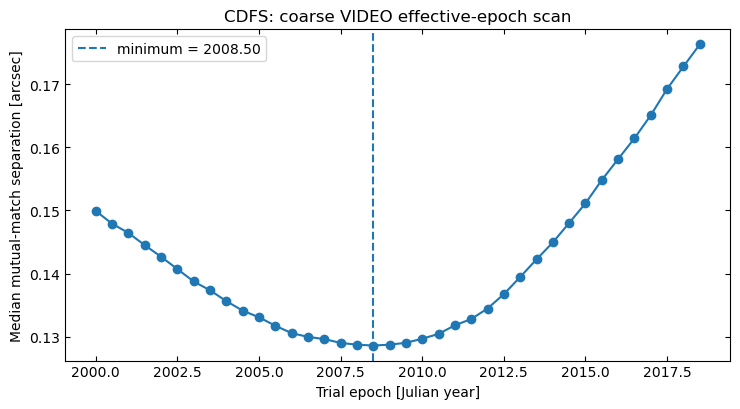

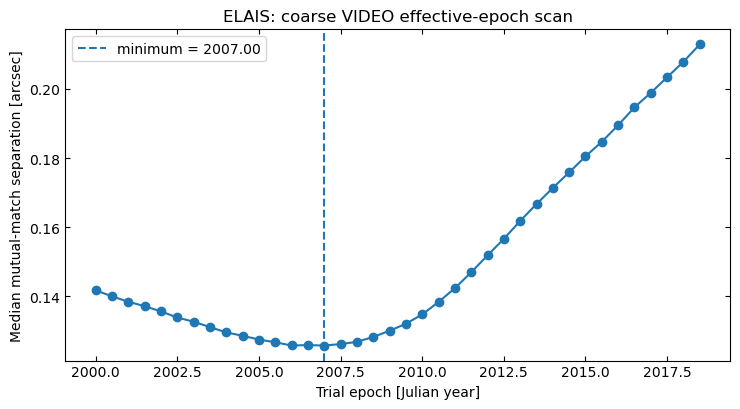

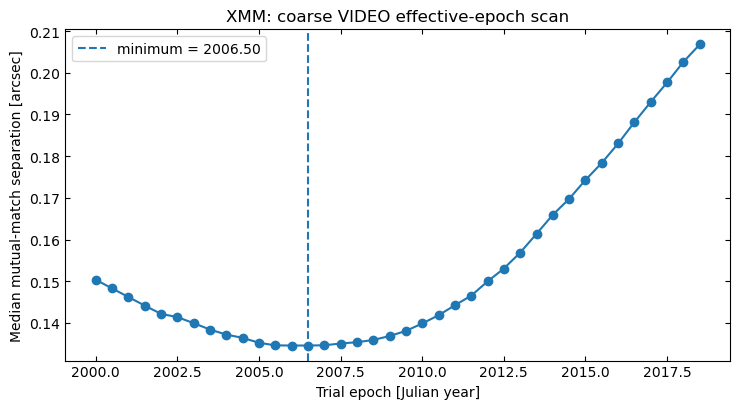

In [11]:
for field, scan in coarse_scans.items():

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "median_sep_arcsec"
        ],
        marker="o",
    )

    ax.axvline(
        coarse_best_epochs[
            field
        ],
        linestyle="--",
        label=(
            "minimum = "
            f"{coarse_best_epochs[field]:.2f}"
        ),
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Median mutual-match separation [arcsec]"
    )

    ax.set_title(
        f"{field}: coarse VIDEO effective-epoch scan"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Coarse-scan match-count plots

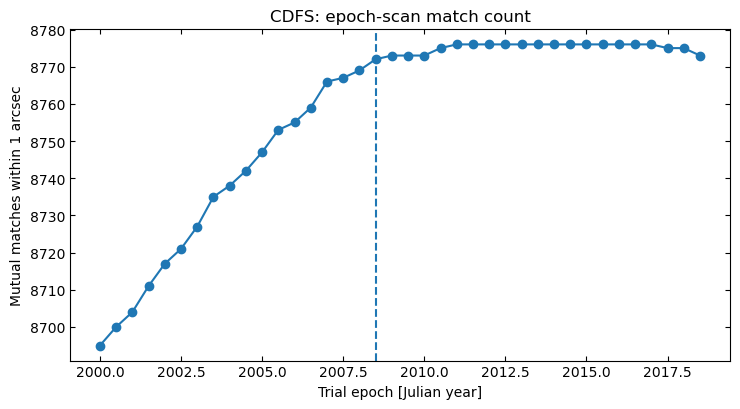

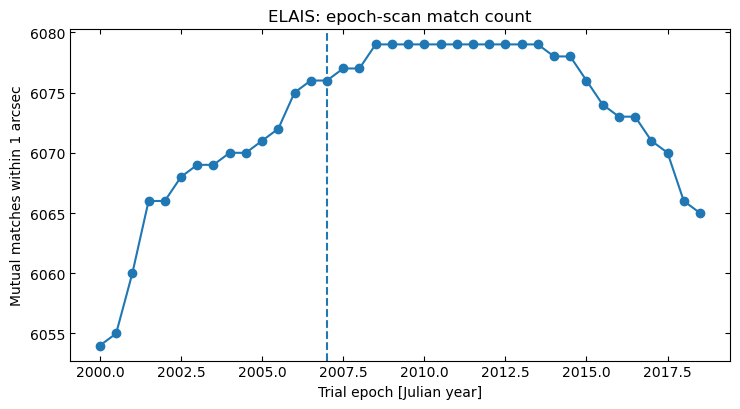

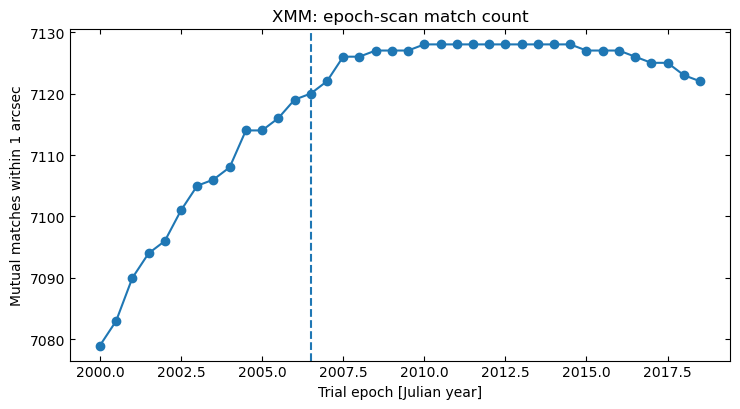

In [12]:
for field, scan in coarse_scans.items():

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "nmatch"
        ],
        marker="o",
    )

    ax.axvline(
        coarse_best_epochs[
            field
        ],
        linestyle="--",
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Mutual matches within 1 arcsec"
    )

    ax.set_title(
        f"{field}: epoch-scan match count"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    fig.tight_layout()
    plt.show()

### Fine effective-epoch scans — 0.1-year spacing

Each coarse minimum is refined over a \(\pm 1\)-year interval in 0.1-year steps. These data-derived effective epochs are used for the final Monster–VIDEO matches.

In [13]:
fine_scans = {}
VIDEO_EFFECTIVE_EPOCH = {}

for field in VIDEO_FILES:

    centre = coarse_best_epochs[
        field
    ]

    fine_grid = np.round(
        np.arange(
            centre
            - 1.0,
            centre
            + 1.0
            + 0.05,
            0.1,
        ),
        10,
    )

    scan = scan_effective_epoch(
        field,
        fine_grid,
    )

    fine_scans[
        field
    ] = scan

    VIDEO_EFFECTIVE_EPOCH[
        field
    ] = best_epoch(
        scan
    )

effective_epoch_table = pd.DataFrame(
    {
        "field":
            list(
                VIDEO_EFFECTIVE_EPOCH.keys()
            ),
        "effective_epoch_jyear":
            list(
                VIDEO_EFFECTIVE_EPOCH.values()
            ),
        "effective_epoch_mjd":
            [
                Time(
                    epoch,
                    format="jyear",
                ).mjd
                for epoch
                in VIDEO_EFFECTIVE_EPOCH.values()
            ],
    }
)

display(
    effective_epoch_table
)

,field,effective_epoch_jyear,effective_epoch_mjd
0,CDFS,2008.2,54539.550
1,ELAIS,2006.8,54028.200
2,XMM,2005.7,53626.425


### Fine-scan separation and match-count diagnostics

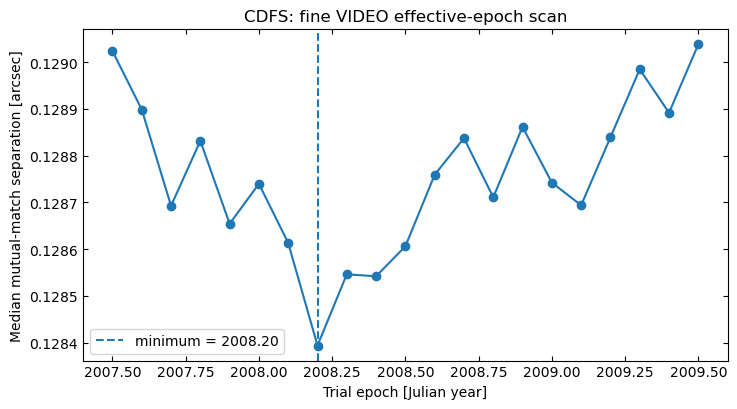

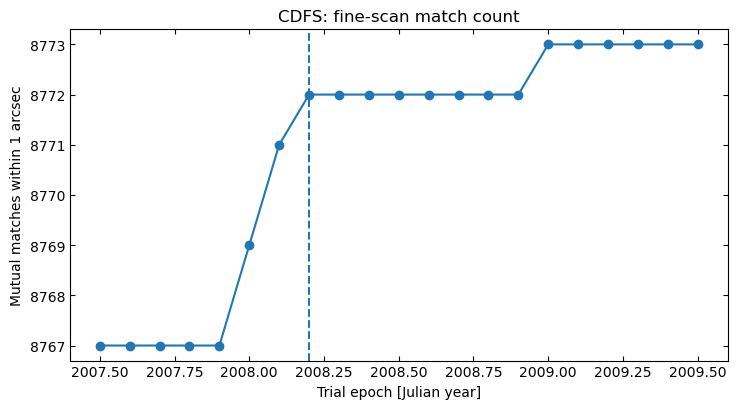

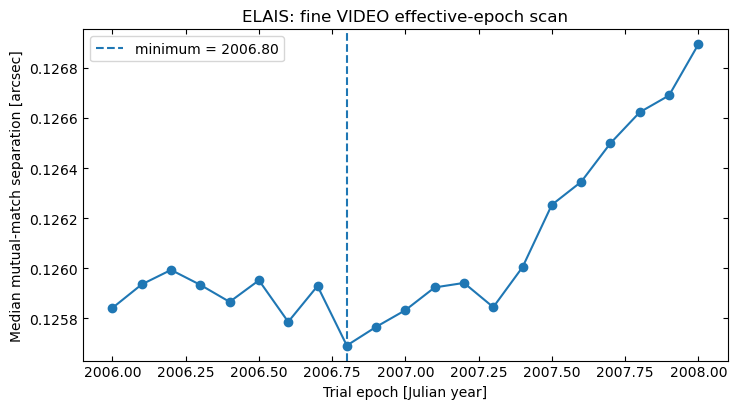

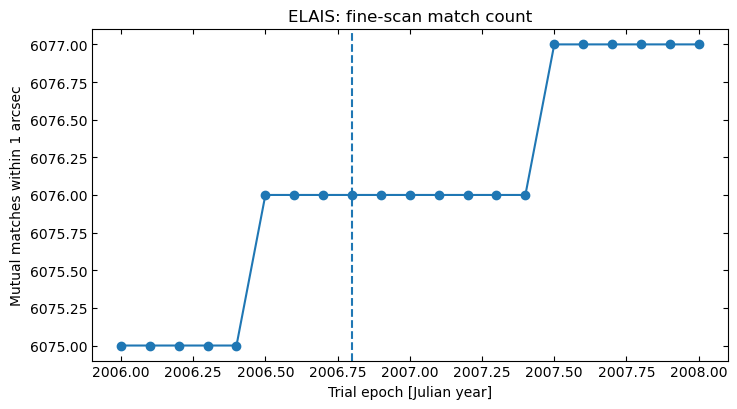

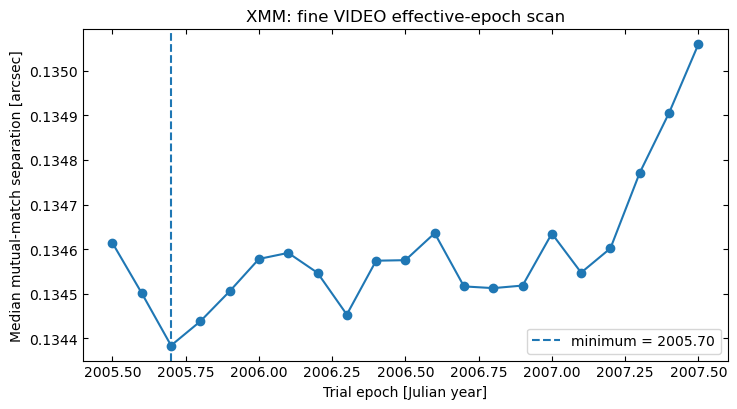

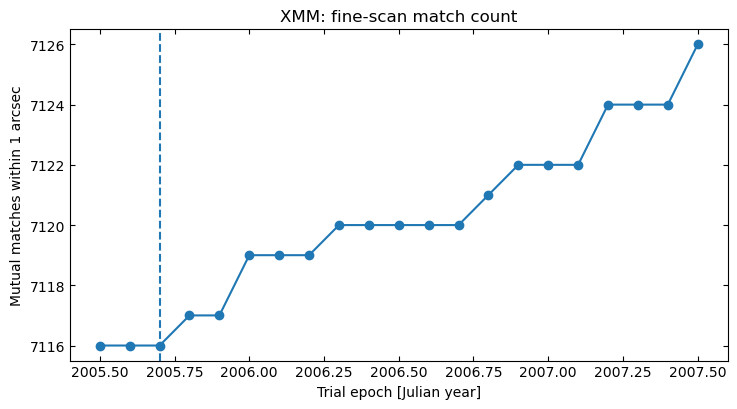

In [14]:
for field, scan in fine_scans.items():

    best = VIDEO_EFFECTIVE_EPOCH[
        field
    ]

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "median_sep_arcsec"
        ],
        marker="o",
    )

    ax.axvline(
        best,
        linestyle="--",
        label=(
            f"minimum = {best:.2f}"
        ),
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Median mutual-match separation [arcsec]"
    )

    ax.set_title(
        f"{field}: fine VIDEO effective-epoch scan"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.2,
        )
    )

    ax.plot(
        scan[
            "epoch"
        ],
        scan[
            "nmatch"
        ],
        marker="o",
    )

    ax.axvline(
        best,
        linestyle="--",
    )

    ax.set_xlabel(
        "Trial epoch [Julian year]"
    )

    ax.set_ylabel(
        "Mutual matches within 1 arcsec"
    )

    ax.set_title(
        f"{field}: fine-scan match count"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    fig.tight_layout()
    plt.show()

### Construct the selected Z-band calibration sample

For each field, the final selection is applied after matching:

- Monster-side isolation \(>1\) arcsec;
- mutual nearest-neighbour match within 0.5 arcsec;
- secure calibration separation \(<0.3\) arcsec;
- finite positive VIDEO Z and Monster DES i/z fluxes and uncertainties;
- S/N \(\geq 50\) in all three required fluxes;
- `KS_CLASS_STAR >= 0.90` for stellar morphology;
- `KS_FLAGS == 0` for the classifier/detection measurement;
- `Z_FLAGS == 0` for the calibrated Z measurement;
- \(14 < Z_{\rm VIDEO} < 20\) AB mag.

VIDEO `Z_FLUX_APER_2` is converted to nJy using the verified zeropoint-30 scale. The Ks quantities are used only for stellar selection. The measured Z ratio is

$$
R_Z
=
\frac{F_{\mathrm{Monster,DES},z}}
     {F_{\mathrm{VIDEO},Z}}.
$$


In [15]:
def process_video_z_field(
    field,
):
    """Construct the selected Z calibration sample for one VIDEO field."""

    video = video_tables[
        field
    ]

    monster = monster_tables[
        field
    ]

    target_mjd = Time(
        VIDEO_EFFECTIVE_EPOCH[
            field
        ],
        format="jyear",
    ).mjd

    ra_video = float_array(
        video[
            "RA2000"
        ]
    )

    dec_video = float_array(
        video[
            "DEC2000"
        ]
    )

    video_coords = SkyCoord(
        ra=ra_video
        * u.deg,
        dec=dec_video
        * u.deg,
        frame="icrs",
    )

    (
        monster_coords,
        monster_use_index,
    ) = propagate_monster_pm_only(
        monster,
        target_mjd,
    )

    isolation = isolate_mask(
        monster_coords,
        MONSTER_ISOLATION_RADIUS,
    )

    isolated_coords = monster_coords[
        isolation
    ]

    isolated_monster_index = monster_use_index[
        isolation
    ]

    (
        gold,
        idx_video,
        separation,
    ) = mutual_nn_match(
        isolated_coords,
        video_coords,
        MATCH_RADIUS,
    )

    gold_monster_index = (
        isolated_monster_index[
            gold
        ]
    )

    gold_video_index = (
        idx_video[
            gold
        ]
    )

    gold_separation_arcsec = (
        separation[
            gold
        ]
        .to_value(
            u.arcsec
        )
    )

    if len(
        gold_monster_index
    ) == 0:
        raise RuntimeError(
            f"{field}: no Gold matches."
        )

    monster_id = integer_array(
        monster[
            "id"
        ][
            gold_monster_index
        ]
    )

    monster_i_flux = float_array(
        monster[
            "monster_DES_i_flux"
        ][
            gold_monster_index
        ]
    )

    monster_i_flux_err = float_array(
        monster[
            "monster_DES_i_fluxErr"
        ][
            gold_monster_index
        ]
    )

    monster_z_flux = float_array(
        monster[
            "monster_DES_z_flux"
        ][
            gold_monster_index
        ]
    )

    monster_z_flux_err = float_array(
        monster[
            "monster_DES_z_fluxErr"
        ][
            gold_monster_index
        ]
    )

    video_z_flux_adu = float_array(
        video[
            "Z_FLUX_APER_2"
        ][
            gold_video_index
        ]
    )

    video_z_flux_err_adu = float_array(
        video[
            "Z_FLUXERR_APER_2"
        ][
            gold_video_index
        ]
    )

    video_z_mag = float_array(
        video[
            "Z_MAG_APER_2"
        ][
            gold_video_index
        ]
    )

    video_z_mag_err = float_array(
        video[
            "Z_MAGERR_APER_2"
        ][
            gold_video_index
        ]
    )

    video_class_star = float_array(
        video[
            "KS_CLASS_STAR"
        ][
            gold_video_index
        ]
    )

    video_ks_flags = integer_array(
        video[
            "KS_FLAGS"
        ][
            gold_video_index
        ],
        fill_value=999,
    )

    video_z_flags = integer_array(
        video[
            "Z_FLAGS"
        ][
            gold_video_index
        ],
        fill_value=999,
    )

    video_z_flux_njy = (
        video_z_flux_adu
        * VIDEO_ADU_TO_NJY
    )

    video_z_flux_err_njy = (
        video_z_flux_err_adu
        * VIDEO_ADU_TO_NJY
    )

    monster_i_snr = safe_snr(
        monster_i_flux,
        monster_i_flux_err,
    )

    monster_z_snr = safe_snr(
        monster_z_flux,
        monster_z_flux_err,
    )

    video_z_snr = safe_snr(
        video_z_flux_njy,
        video_z_flux_err_njy,
    )

    colour = np.full(
        len(
            monster_id
        ),
        np.nan,
        dtype=float,
    )

    valid_colour = (
        np.isfinite(
            monster_i_flux
        )
        & np.isfinite(
            monster_z_flux
        )
        & (
            monster_i_flux
            > 0.0
        )
        & (
            monster_z_flux
            > 0.0
        )
    )

    colour[
        valid_colour
    ] = (
        -2.5
        * np.log10(
            monster_i_flux[
                valid_colour
            ]
            / monster_z_flux[
                valid_colour
            ]
        )
    )

    ratio = np.full(
        len(
            monster_id
        ),
        np.nan,
        dtype=float,
    )

    valid_ratio = (
        np.isfinite(
            monster_z_flux
        )
        & np.isfinite(
            video_z_flux_njy
        )
        & (
            monster_z_flux
            > 0.0
        )
        & (
            video_z_flux_njy
            > 0.0
        )
    )

    ratio[
        valid_ratio
    ] = (
        monster_z_flux[
            valid_ratio
        ]
        / video_z_flux_njy[
            valid_ratio
        ]
    )

    finite_photometry = (
        np.isfinite(
            colour
        )
        & np.isfinite(
            ratio
        )
        & np.isfinite(
            video_z_mag
        )
        & np.isfinite(
            video_z_mag_err
        )
    )

    secure_separation = (
        gold_separation_arcsec
        < CALIBRATION_MATCH_RADIUS_ARCSEC
    )

    high_snr = (
        (
            video_z_snr
            >= MINIMUM_SNR
        )
        & (
            monster_i_snr
            >= MINIMUM_SNR
        )
        & (
            monster_z_snr
            >= MINIMUM_SNR
        )
    )

    stellar = (
        np.isfinite(
            video_class_star
        )
        & (
            video_class_star
            >= VIDEO_STAR_CLASS_MIN
        )
    )

    clean_flags = (
        (video_z_flags == 0)
        & (video_ks_flags == 0)
    )

    safe_magnitude = (
        video_z_mag
        > MINIMUM_Z_AB
    ) & (
        video_z_mag
        < MAXIMUM_Z_AB
    )

    selected_mask = (
        finite_photometry
        & secure_separation
        & high_snr
        & stellar
        & clean_flags
        & safe_magnitude
    )

    selected = Table()

    selected[
        "field"
    ] = np.full(
        np.count_nonzero(
            selected_mask
        ),
        field,
        dtype="U8",
    )

    selected[
        "monster_id"
    ] = monster_id[
        selected_mask
    ]

    selected[
        "monster_original_index"
    ] = gold_monster_index[
        selected_mask
    ].astype(
        np.int64
    )

    selected[
        "video_original_index"
    ] = gold_video_index[
        selected_mask
    ].astype(
        np.int64
    )

    selected[
        "separation_arcsec"
    ] = gold_separation_arcsec[
        selected_mask
    ]

    selected[
        "video_z_mag_ab"
    ] = video_z_mag[
        selected_mask
    ]

    selected[
        "video_z_magErr"
    ] = video_z_mag_err[
        selected_mask
    ]

    selected[
        "video_ks_class_star"
    ] = video_class_star[
        selected_mask
    ]

    selected[
        "video_ks_flags"
    ] = video_ks_flags[
        selected_mask
    ]

    selected[
        "video_z_flags"
    ] = video_z_flags[
        selected_mask
    ]

    selected[
        "video_z_flux_njy"
    ] = video_z_flux_njy[
        selected_mask
    ]

    selected[
        "video_z_fluxErr_njy"
    ] = video_z_flux_err_njy[
        selected_mask
    ]

    selected[
        "video_z_snr"
    ] = video_z_snr[
        selected_mask
    ]

    selected[
        "monster_i_flux_njy"
    ] = monster_i_flux[
        selected_mask
    ]

    selected[
        "monster_i_fluxErr_njy"
    ] = monster_i_flux_err[
        selected_mask
    ]

    selected[
        "monster_i_snr"
    ] = monster_i_snr[
        selected_mask
    ]

    selected[
        "monster_z_flux_njy"
    ] = monster_z_flux[
        selected_mask
    ]

    selected[
        "monster_z_fluxErr_njy"
    ] = monster_z_flux_err[
        selected_mask
    ]

    selected[
        "monster_z_snr"
    ] = monster_z_snr[
        selected_mask
    ]

    selected[
        "monster_iz_colour"
    ] = colour[
        selected_mask
    ]

    selected[
        "measured_ratio"
    ] = ratio[
        selected_mask
    ]

    summary = {
        "field":
            field,
        "monster_rows":
            len(
                monster
            ),
        "video_rows":
            len(
                video
            ),
        "pm_valid_monster":
            len(
                monster_coords
            ),
        "isolated_monster":
            int(
                np.count_nonzero(
                    isolation
                )
            ),
        "gold_matches_0p5":
            len(
                gold_monster_index
            ),
        "secure_matches_0p3":
            int(
                np.count_nonzero(
                    secure_separation
                )
            ),
        "selected_calibration_stars":
            int(
                np.count_nonzero(
                    selected_mask
                )
            ),
        "median_gold_separation_arcsec":
            float(
                np.median(
                    gold_separation_arcsec
                )
            ),
        "effective_epoch_jyear":
            VIDEO_EFFECTIVE_EPOCH[
                field
            ],
    }

    return (
        selected,
        summary,
    )


### Process CDFS, ELAIS-S1, and XMM-LSS

Each field is processed independently before the selected observations are combined.

In [16]:
selected_field_tables = []

field_summary_records = []

for field in VIDEO_FILES:

    print(
        f"Processing {field} ..."
    )

    (
        selected,
        summary,
    ) = process_video_z_field(
        field
    )

    selected_field_tables.append(
        selected
    )

    field_summary_records.append(
        summary
    )

    print(
        f"  Gold within 0.5 arcsec : "
        f"{summary['gold_matches_0p5']:,}"
    )

    print(
        f"  Secure within 0.3 arcsec: "
        f"{summary['secure_matches_0p3']:,}"
    )

    print(
        f"  Selected calibration stars: "
        f"{summary['selected_calibration_stars']:,}"
    )


all_z_calibration_observations = vstack(
    selected_field_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

field_processing_summary = pd.DataFrame(
    field_summary_records
)

display(
    field_processing_summary
)

print(
    "\nCombined selected observations:",
    f"{len(all_z_calibration_observations):,}",
)

Processing CDFS ...
  Gold within 0.5 arcsec : 13,052
  Secure within 0.3 arcsec: 12,675
  Selected calibration stars: 2,505
Processing ELAIS ...
  Gold within 0.5 arcsec : 9,359
  Secure within 0.3 arcsec: 9,110
  Selected calibration stars: 4,799
Processing XMM ...
  Gold within 0.5 arcsec : 11,326
  Secure within 0.3 arcsec: 10,725
  Selected calibration stars: 4,124


,field,monster_rows,video_rows,pm_valid_monster,isolated_monster,gold_matches_0p5,secure_matches_0p3,selected_calibration_stars,median_gold_separation_arcsec,effective_epoch_jyear
0,CDFS,55487,1138485,43039,42735,13052,12675,2505,0.129526,2008.2
1,ELAIS,35684,842337,27989,27821,9359,9110,4799,0.127276,2006.8
2,XMM,48013,1279857,38315,38253,11326,10725,4124,0.134432,2005.7



Combined selected observations: 11,428


### Check uniqueness and save the selected observations

The three VIDEO fields are disjoint on the sky, but the Monster source ID is nevertheless checked explicitly. If a duplicate exists, the best observation is chosen by highest VIDEO Z S/N and then by smallest separation.

This produces one calibration row per Monster source.

In [17]:
all_ids = integer_array(
    all_z_calibration_observations[
        "monster_id"
    ]
)

all_snr = float_array(
    all_z_calibration_observations[
        "video_z_snr"
    ]
)

all_sep = float_array(
    all_z_calibration_observations[
        "separation_arcsec"
    ]
)

order = np.lexsort(
    (
        all_sep,
        -all_snr,
        all_ids,
    )
)

ordered = (
    all_z_calibration_observations[
        order
    ]
)

ordered_ids = integer_array(
    ordered[
        "monster_id"
    ]
)

_, first = np.unique(
    ordered_ids,
    return_index=True,
)

unique_z_calibration_sample = (
    ordered[
        np.sort(
            first
        )
    ]
)

print(
    "Selected observations:",
    f"{len(all_z_calibration_observations):,}",
)

print(
    "Unique Monster sources:",
    f"{len(unique_z_calibration_sample):,}",
)

print(
    "Repeated observations removed:",
    f"{len(all_z_calibration_observations) - len(unique_z_calibration_sample):,}",
)

ALL_OBSERVATIONS_PATH = (
    OUTPUT_DIR
    / "video_z_calibration_observations_all_fields.fits"
)

UNIQUE_SOURCES_PATH = (
    OUTPUT_DIR
    / "video_z_calibration_unique_sources.fits"
)

FIELD_SUMMARY_PATH = (
    OUTPUT_DIR
    / "video_z_field_processing_summary.csv"
)

all_z_calibration_observations.write(
    ALL_OBSERVATIONS_PATH,
    overwrite=True,
)

unique_z_calibration_sample.write(
    UNIQUE_SOURCES_PATH,
    overwrite=True,
)

field_processing_summary.to_csv(
    FIELD_SUMMARY_PATH,
    index=False,
)

print("\nSaved:")
print(
    f"  {ALL_OBSERVATIONS_PATH}"
)
print(
    f"  {UNIQUE_SOURCES_PATH}"
)
print(
    f"  {FIELD_SUMMARY_PATH}"
)

Selected observations: 11,428
Unique Monster sources: 11,428
Repeated observations removed: 0

Saved:
  data/outputs/Monster_VIDEO_Z/video_z_calibration_observations_all_fields.fits
  data/outputs/Monster_VIDEO_Z/video_z_calibration_unique_sources.fits
  data/outputs/Monster_VIDEO_Z/video_z_field_processing_summary.csv


### Inspect the colour–ratio relation by VIDEO field

This is the first direct check of whether the three independent VIDEO fields follow the same transformation.

A large field-dependent vertical displacement would argue against one global VIDEO calibration. Similar loci with small relative offsets support a common field-balanced relation.

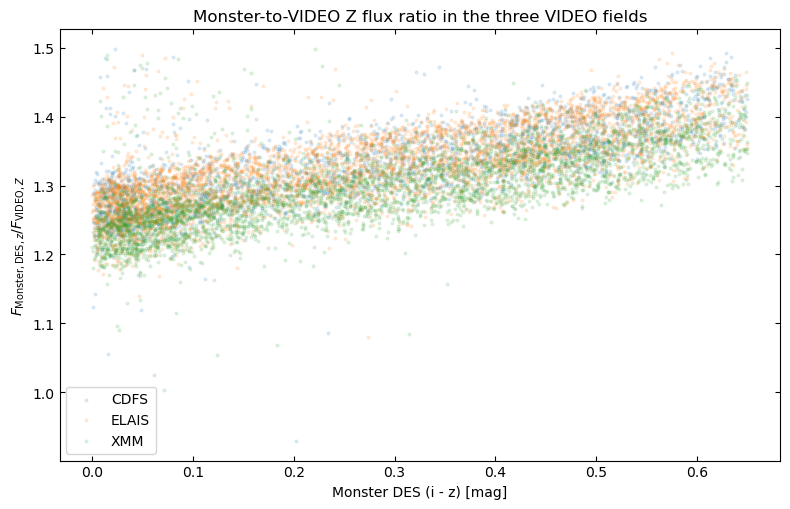

In [18]:
colour = float_array(
    unique_z_calibration_sample[
        "monster_iz_colour"
    ]
)

ratio = float_array(
    unique_z_calibration_sample[
        "measured_ratio"
    ]
)

field_name = np.asarray(
    unique_z_calibration_sample[
        "field"
    ]
).astype(
    str
)

plot_mask = (
    np.isfinite(
        colour
    )
    & np.isfinite(
        ratio
    )
    & (
        colour
        >= COLOUR_MIN
    )
    & (
        colour
        <= COLOUR_MAX
    )
    & (
        ratio
        > 0.5
    )
    & (
        ratio
        < 1.5
    )
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5.2,
    )
)

for field in VIDEO_FILES:

    selection = (
        plot_mask
        & (
            field_name
            == field
        )
    )

    ax.scatter(
        colour[
            selection
        ],
        ratio[
            selection
        ],
        s=4,
        alpha=0.12,
        label=field,
    )

ax.set_xlabel(
    "Monster DES (i - z) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},z}/F_{\mathrm{VIDEO},Z}$"
)

ax.set_title(
    "Monster-to-VIDEO Z flux ratio in the three VIDEO fields"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend()

fig.tight_layout()
plt.show()

### Construct field-balanced spline nodes

Because only three field-level VIDEO catalogues are available, the balancing procedure differs slightly from the 88-tile VIKING case.

For each spline node:

1. sources are assigned to the colour interval bounded by the midpoints between adjacent nodes;
2. ratios are clipped independently inside each VIDEO field using iterative 4-NMAD clipping;
3. the median ratio of each field is calculated;
4. the global node is the **median of the available field medians**.

No field-level clipping is performed: with only three fields it would be statistically inappropriate to reject a field automatically. Instead, the field-to-field scatter is retained as a diagnostic.

At least two fields must contribute to every final node. Ideally all three fields should contribute throughout the calibrated interval.

In [19]:
def node_edges(
    nodes,
):
    """Return bin edges centred on the supplied nodes."""

    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    midpoints = 0.5 * (
        nodes[
            1:
        ]
        + nodes[
            :-1
        ]
    )

    first = (
        nodes[
            0
        ]
        - 0.5
        * (
            nodes[
                1
            ]
            - nodes[
                0
            ]
        )
    )

    last = (
        nodes[
            -1
        ]
        + 0.5
        * (
            nodes[
                -1
            ]
            - nodes[
                -2
            ]
        )
    )

    return np.concatenate(
        (
            [
                first,
            ],
            midpoints,
            [
                last,
            ],
        )
    )


def construct_field_balanced_nodes(
    table,
    nodes,
    allowed_fields=None,
):
    """Construct robust field-balanced ratio nodes."""

    if allowed_fields is None:
        allowed_fields = list(
            VIDEO_FILES
        )

    nodes = np.asarray(
        nodes,
        dtype=float,
    )

    edges = node_edges(
        nodes
    )

    colours = float_array(
        table[
            "monster_iz_colour"
        ]
    )

    ratios = float_array(
        table[
            "measured_ratio"
        ]
    )

    fields = np.asarray(
        table[
            "field"
        ]
    ).astype(
        str
    )

    records = []

    field_records = []

    for node_index, node in enumerate(
        nodes
    ):

        lower = edges[
            node_index
        ]

        upper = edges[
            node_index
            + 1
        ]

        # Include the upper boundary only in the final interval.
        if node_index == len(
            nodes
        ) - 1:

            in_interval = (
                np.isfinite(
                    colours
                )
                & np.isfinite(
                    ratios
                )
                & (
                    colours
                    >= lower
                )
                & (
                    colours
                    <= upper
                )
            )

        else:

            in_interval = (
                np.isfinite(
                    colours
                )
                & np.isfinite(
                    ratios
                )
                & (
                    colours
                    >= lower
                )
                & (
                    colours
                    < upper
                )
            )

        field_medians = []

        for field in allowed_fields:

            selection = (
                in_interval
                & (
                    fields
                    == field
                )
            )

            values = ratios[
                selection
            ]

            number_before = len(
                values
            )

            if (
                number_before
                < MINIMUM_STARS_PER_FIELD_BIN
            ):
                continue

            keep = iterative_nmad_clip(
                values,
                threshold=STAR_CLIP_THRESHOLD,
            )

            clipped = values[
                keep
            ]

            number_after = len(
                clipped
            )

            if (
                number_after
                < MINIMUM_STARS_PER_FIELD_BIN
            ):
                continue

            field_median = float(
                np.median(
                    clipped
                )
            )

            field_nmad = robust_nmad(
                clipped
            )

            field_medians.append(
                field_median
            )

            field_records.append(
                {
                    "node_colour":
                        float(
                            node
                        ),
                    "field":
                        field,
                    "colour_lower":
                        float(
                            lower
                        ),
                    "colour_upper":
                        float(
                            upper
                        ),
                    "n_before_clip":
                        number_before,
                    "n_after_clip":
                        number_after,
                    "field_median_ratio":
                        field_median,
                    "field_ratio_nmad":
                        field_nmad,
                }
            )

        field_medians = np.asarray(
            field_medians,
            dtype=float,
        )

        if len(
            field_medians
        ) < MINIMUM_FIELDS_PER_NODE:

            records.append(
                {
                    "node_colour":
                        float(
                            node
                        ),
                    "node_ratio":
                        np.nan,
                    "node_uncertainty":
                        np.nan,
                    "field_to_field_nmad":
                        np.nan,
                    "n_fields":
                        len(
                            field_medians
                        ),
                }
            )

            continue

        node_ratio = float(
            np.median(
                field_medians
            )
        )

        field_scatter = robust_nmad(
            field_medians
        )

        if (
            np.isfinite(
                field_scatter
            )
            and len(
                field_medians
            ) > 1
        ):
            node_uncertainty = (
                field_scatter
                / np.sqrt(
                    len(
                        field_medians
                    )
                )
            )
        else:
            node_uncertainty = np.nan

        records.append(
            {
                "node_colour":
                    float(
                        node
                    ),
                "node_ratio":
                    node_ratio,
                "node_uncertainty":
                    node_uncertainty,
                "field_to_field_nmad":
                    field_scatter,
                "n_fields":
                    len(
                        field_medians
                    ),
            }
        )

    return (
        pd.DataFrame(
            records
        ),
        pd.DataFrame(
            field_records
        ),
    )

### Diagnostic field-balanced nodes using all three fields

In [20]:
diagnostic_node_table, diagnostic_field_nodes = (
    construct_field_balanced_nodes(
        unique_z_calibration_sample,
        FINAL_NODES,
    )
)

display(
    diagnostic_node_table
)

if np.any(
    ~np.isfinite(
        diagnostic_node_table[
            "node_ratio"
        ].to_numpy(
            dtype=float
        )
    )
):
    raise RuntimeError(
        "At least one final node lacks sufficient VIDEO field support. "
        "Inspect diagnostic_node_table before changing the colour range."
    )

if np.any(
    diagnostic_node_table[
        "n_fields"
    ].to_numpy(
        dtype=int
    )
    < MINIMUM_FIELDS_PER_NODE
):
    raise RuntimeError(
        "At least one final node is supported by fewer than "
        f"{MINIMUM_FIELDS_PER_NODE} fields."
    )

,node_colour,node_ratio,node_uncertainty,field_to_field_nmad,n_fields
0,0.000000,1.267761,0.001333,0.002309,3
1,0.072222,1.271927,0.002733,0.004733,3
2,0.144444,1.294786,0.000297,0.000514,3
3,0.216667,1.311337,0.001349,0.002337,3
4,0.288889,1.330597,0.001741,0.003016,3
5,0.361111,1.343368,0.000989,0.001713,3
6,0.433333,1.353804,0.011187,0.019376,3
7,0.505556,1.372399,0.006688,0.011583,3
8,0.577778,1.395798,0.001309,0.002268,3
9,0.650000,1.424036,0.000596,0.001033,3


### Field-to-field node consistency

Each marker is an independently measured field median in one colour interval. The line connects the three-field-balanced node values.

This plot is the direct VIDEO analogue of the tile-consistency diagnostics in the VIKING calibration.

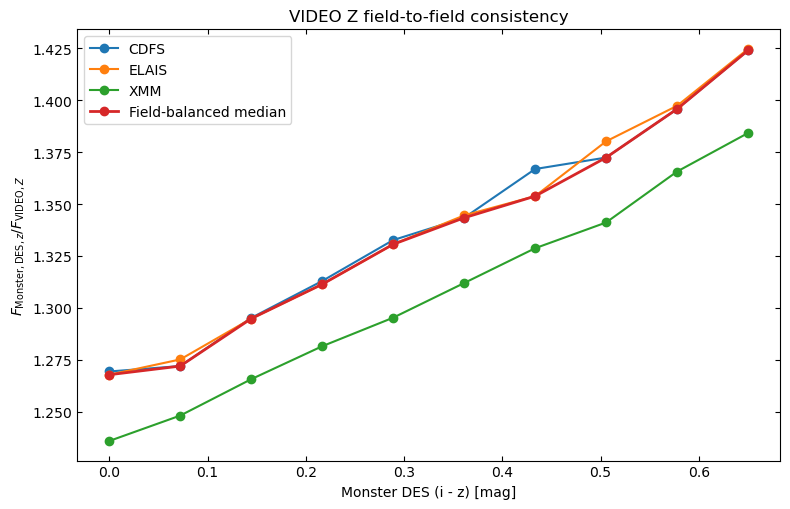

In [21]:
fig, ax = plt.subplots(
    figsize=(
        8,
        5.2,
    )
)

for field in VIDEO_FILES:

    sub = diagnostic_field_nodes[
        diagnostic_field_nodes[
            "field"
        ]
        == field
    ]

    ax.plot(
        sub[
            "node_colour"
        ],
        sub[
            "field_median_ratio"
        ],
        marker="o",
        label=field,
    )

ax.plot(
    diagnostic_node_table[
        "node_colour"
    ],
    diagnostic_node_table[
        "node_ratio"
    ],
    marker="o",
    linewidth=2,
    label="Field-balanced median",
)

ax.set_xlabel(
    "Monster DES (i - z) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},z}/F_{\mathrm{VIDEO},Z}$"
)

ax.set_title(
    "VIDEO Z field-to-field consistency"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend()

fig.tight_layout()
plt.show()

### Leave-one-field-out validation

The most important robustness test uses genuinely independent sky areas.

For each iteration:

- one VIDEO field is withheld;
- the field-balanced nodes are fitted using only the other two fields;
- the spline predicts the withheld field;
- residuals are measured without refitting that field.

The ratio residual is

$$
\Delta R_Z
=
R_{Z,\mathrm{measured}}
-
R_{Z,\mathrm{model}}.
$$

For an intuitive photometric diagnostic, the predicted VIDEO flux is

$$
F_{\mathrm{VIDEO},Z}^{\mathrm{pred}}
=
\frac{F_{\mathrm{Monster,DES},z}}
     {R_{Z,\mathrm{model}}},
$$

and

$$
\Delta m_Z
=
-2.5\log_{10}
\left(
\frac{F_{\mathrm{VIDEO},Z}^{\mathrm{pred}}}
     {F_{\mathrm{VIDEO},Z}^{\mathrm{observed}}}
\right).
$$

In [22]:
validation_tables = []

validation_summary_records = []

validation_node_tables = {}

for withheld_field in VIDEO_FILES:

    fitting_fields = [
        field
        for field in VIDEO_FILES
        if field
        != withheld_field
    ]

    fit_nodes, fit_field_nodes = (
        construct_field_balanced_nodes(
            unique_z_calibration_sample,
            FINAL_NODES,
            allowed_fields=fitting_fields,
        )
    )

    if np.any(
        ~np.isfinite(
            fit_nodes[
                "node_ratio"
            ].to_numpy(
                dtype=float
            )
        )
    ):
        raise RuntimeError(
            f"Leave-one-field-out fit for {withheld_field} "
            "has unsupported spline nodes."
        )

    spline = make_interp_spline(
        fit_nodes[
            "node_colour"
        ].to_numpy(
            dtype=float
        ),
        fit_nodes[
            "node_ratio"
        ].to_numpy(
            dtype=float
        ),
        k=3,
    )

    validation_node_tables[
        withheld_field
    ] = fit_nodes

    selection = (
        np.asarray(
            unique_z_calibration_sample[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    validation = (
        unique_z_calibration_sample[
            selection
        ]
    )

    validation_colour = float_array(
        validation[
            "monster_iz_colour"
        ]
    )

    measured_ratio = float_array(
        validation[
            "measured_ratio"
        ]
    )

    monster_z_flux = float_array(
        validation[
            "monster_z_flux_njy"
        ]
    )

    observed_video_flux = float_array(
        validation[
            "video_z_flux_njy"
        ]
    )

    model_ratio = evaluate_spline(
        spline,
        validation_colour,
        FINAL_NODES[
            0
        ],
        FINAL_NODES[
            -1
        ],
    )

    valid = (
        np.isfinite(
            validation_colour
        )
        & np.isfinite(
            measured_ratio
        )
        & np.isfinite(
            model_ratio
        )
        & (
            model_ratio
            > 0.0
        )
        & np.isfinite(
            monster_z_flux
        )
        & (
            monster_z_flux
            > 0.0
        )
        & np.isfinite(
            observed_video_flux
        )
        & (
            observed_video_flux
            > 0.0
        )
    )

    ratio_residual = (
        measured_ratio[
            valid
        ]
        - model_ratio[
            valid
        ]
    )

    fractional_residual = (
        ratio_residual
        / model_ratio[
            valid
        ]
    )

    predicted_video_flux = (
        monster_z_flux[
            valid
        ]
        / model_ratio[
            valid
        ]
    )

    delta_mag = (
        -2.5
        * np.log10(
            predicted_video_flux
            / observed_video_flux[
                valid
            ]
        )
    )

    table = Table()

    table[
        "field"
    ] = np.full(
        np.count_nonzero(
            valid
        ),
        withheld_field,
        dtype="U8",
    )

    table[
        "monster_id"
    ] = integer_array(
        validation[
            "monster_id"
        ][
            valid
        ]
    )

    table[
        "monster_iz_colour"
    ] = validation_colour[
        valid
    ]

    table[
        "measured_ratio"
    ] = measured_ratio[
        valid
    ]

    table[
        "model_ratio"
    ] = model_ratio[
        valid
    ]

    table[
        "ratio_residual"
    ] = ratio_residual

    table[
        "fractional_residual"
    ] = fractional_residual

    table[
        "delta_mag"
    ] = delta_mag

    table[
        "video_z_mag_ab"
    ] = float_array(
        validation[
            "video_z_mag_ab"
        ][
            valid
        ]
    )

    validation_tables.append(
        table
    )

    validation_summary_records.append(
        {
            "withheld_field":
                withheld_field,
            "fitting_fields":
                "+".join(
                    fitting_fields
                ),
            "n_sources":
                len(
                    table
                ),
            "median_ratio_residual":
                float(
                    np.median(
                        ratio_residual
                    )
                ),
            "ratio_residual_nmad":
                robust_nmad(
                    ratio_residual
                ),
            "median_fractional_residual_percent":
                float(
                    100.0
                    * np.median(
                        fractional_residual
                    )
                ),
            "fractional_residual_nmad_percent":
                float(
                    100.0
                    * robust_nmad(
                        fractional_residual
                    )
                ),
            "median_delta_mag":
                float(
                    np.median(
                        delta_mag
                    )
                ),
            "delta_mag_nmad":
                robust_nmad(
                    delta_mag
                ),
        }
    )

validation_residuals = vstack(
    validation_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

validation_summary = pd.DataFrame(
    validation_summary_records
)

display(
    validation_summary
)

,withheld_field,fitting_fields,n_sources,median_ratio_residual,ratio_residual_nmad,median_fractional_residual_percent,fractional_residual_nmad_percent,median_delta_mag,delta_mag_nmad
0,CDFS,ELAIS+XMM,2417,0.016882,0.036319,1.297584,2.781543,-0.013998,0.029759
1,ELAIS,CDFS+XMM,4666,0.016068,0.037461,1.233940,2.860851,-0.013315,0.030824
2,XMM,CDFS+ELAIS,3984,-0.029827,0.034482,-2.244177,2.606427,0.024643,0.029038


### Leave-one-field-out residuals versus colour

A successful global VIDEO transformation should leave each withheld field centred close to zero with no strong remaining colour trend.

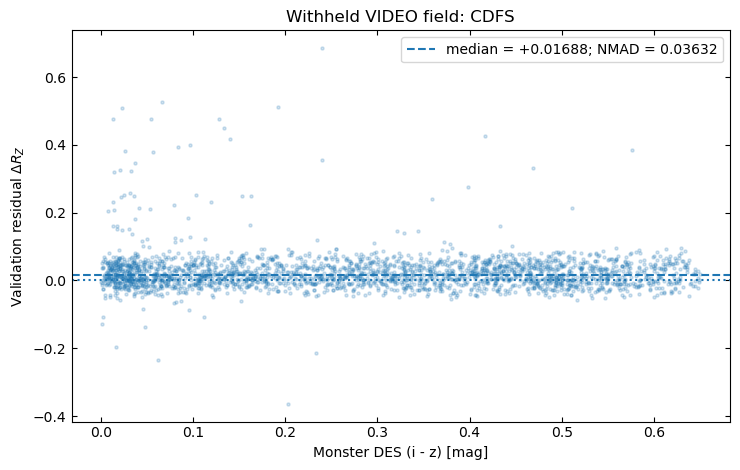

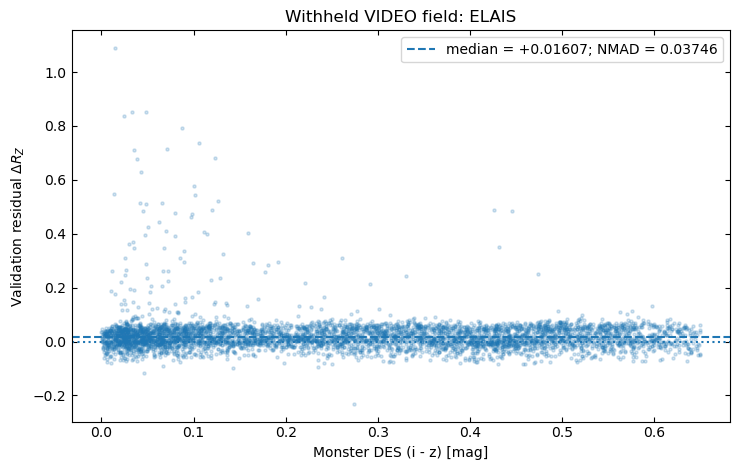

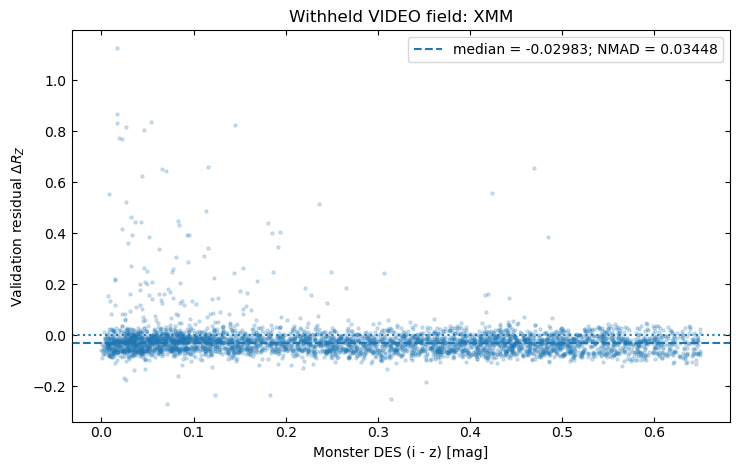

In [23]:
for withheld_field in VIDEO_FILES:

    selection = (
        np.asarray(
            validation_residuals[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    colour_val = float_array(
        validation_residuals[
            "monster_iz_colour"
        ][
            selection
        ]
    )

    residual_val = float_array(
        validation_residuals[
            "ratio_residual"
        ][
            selection
        ]
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.scatter(
        colour_val,
        residual_val,
        s=5,
        alpha=0.20,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            residual_val
        ),
        linestyle="--",
        label=(
            "median = "
            f"{np.nanmedian(residual_val):+.5f}; "
            "NMAD = "
            f"{robust_nmad(residual_val):.5f}"
        ),
    )

    ax.set_xlabel(
        "Monster DES (i - z) [mag]"
    )

    ax.set_ylabel(
        r"Validation residual $\Delta R_Z$"
    )

    ax.set_title(
        f"Withheld VIDEO field: {withheld_field}"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Leave-one-field-out residuals versus VIDEO Z magnitude

This diagnostic tests for residual bright/faint behaviour after the colour relation is applied.

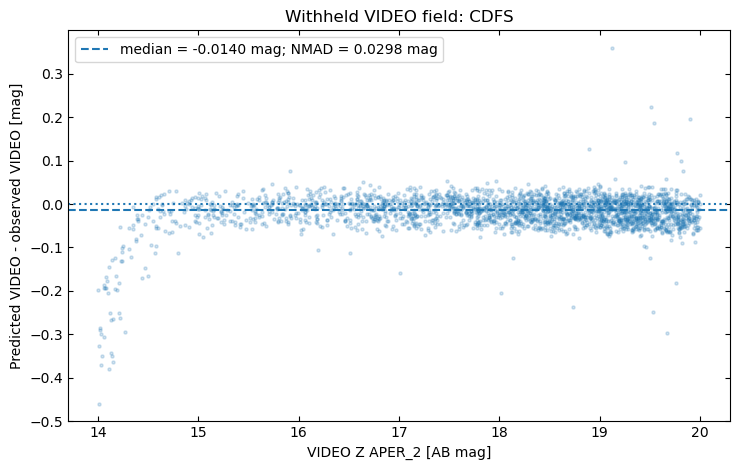

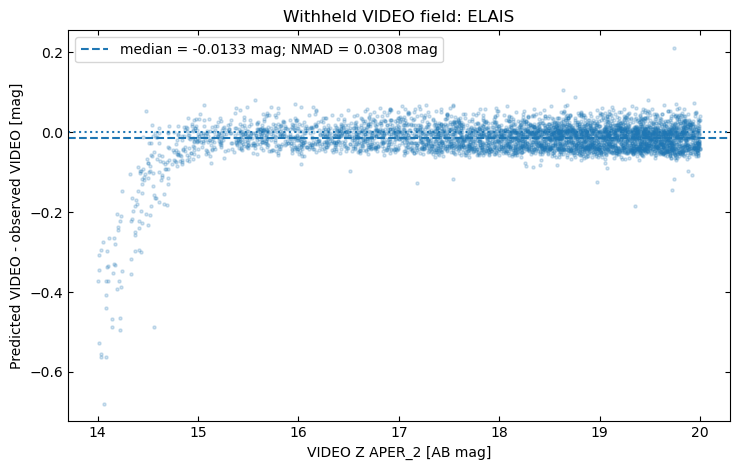

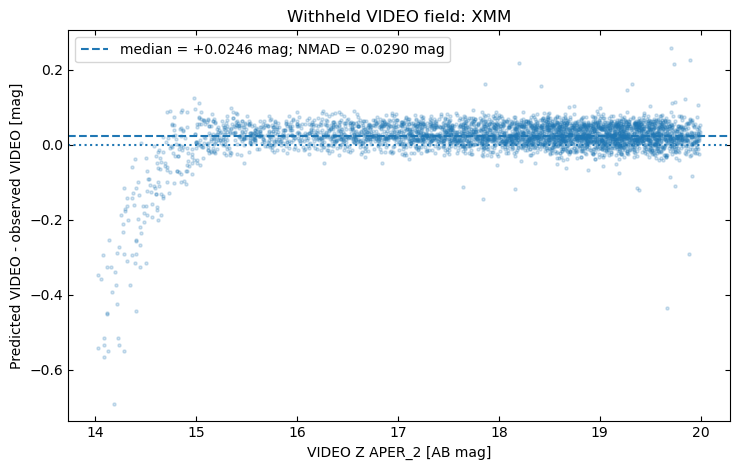

In [24]:
for withheld_field in VIDEO_FILES:

    selection = (
        np.asarray(
            validation_residuals[
                "field"
            ]
        ).astype(
            str
        )
        == withheld_field
    )

    magnitude = float_array(
        validation_residuals[
            "video_z_mag_ab"
        ][
            selection
        ]
    )

    delta_mag = float_array(
        validation_residuals[
            "delta_mag"
        ][
            selection
        ]
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.scatter(
        magnitude,
        delta_mag,
        s=5,
        alpha=0.20,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            delta_mag
        ),
        linestyle="--",
        label=(
            "median = "
            f"{np.nanmedian(delta_mag):+.4f} mag; "
            "NMAD = "
            f"{robust_nmad(delta_mag):.4f} mag"
        ),
    )

    ax.set_xlabel(
        "VIDEO Z APER_2 [AB mag]"
    )

    ax.set_ylabel(
        "Predicted VIDEO - observed VIDEO [mag]"
    )

    ax.set_title(
        f"Withheld VIDEO field: {withheld_field}"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

### Refit the final field-balanced VIDEO Z spline using all three fields

This final fit is performed **only after** the leave-one-field-out validation has completed successfully. The guard below prevents a YAML from being produced from an unvalidated two-field solution if an earlier validation cell failed.


In [25]:
if "validation_summary" not in globals() or len(validation_summary) != len(VIDEO_FILES):
    raise RuntimeError(
        "Leave-one-field-out validation has not completed for all three fields. "
        "Stop here and fix the validation sample before fitting the final spline."
    )

final_node_table, final_field_node_table = (
    construct_field_balanced_nodes(
        unique_z_calibration_sample,
        FINAL_NODES,
        allowed_fields=list(
            VIDEO_FILES
        ),
    )
)

if np.any(
    ~np.isfinite(
        final_node_table[
            "node_ratio"
        ].to_numpy(
            dtype=float
        )
    )
):
    raise RuntimeError(
        "The final VIDEO Z spline has unsupported nodes."
    )

final_z_spline = make_interp_spline(
    final_node_table[
        "node_colour"
    ].to_numpy(
        dtype=float
    ),
    final_node_table[
        "node_ratio"
    ].to_numpy(
        dtype=float
    ),
    k=3,
)

final_colour_grid = np.linspace(
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
    1000,
)

final_grid_ratio = final_z_spline(
    final_colour_grid
)

if np.any(
    ~np.isfinite(
        final_grid_ratio
    )
):
    raise RuntimeError(
        "Final spline contains non-finite values inside the calibrated interval."
    )

if np.any(
    final_grid_ratio
    <= 0.0
):
    raise RuntimeError(
        "Final spline contains non-positive flux ratios."
    )

display(
    final_node_table
)


,node_colour,node_ratio,node_uncertainty,field_to_field_nmad,n_fields
0,0.000000,1.267761,0.001333,0.002309,3
1,0.072222,1.271927,0.002733,0.004733,3
2,0.144444,1.294786,0.000297,0.000514,3
3,0.216667,1.311337,0.001349,0.002337,3
4,0.288889,1.330597,0.001741,0.003016,3
5,0.361111,1.343368,0.000989,0.001713,3
6,0.433333,1.353804,0.011187,0.019376,3
7,0.505556,1.372399,0.006688,0.011583,3
8,0.577778,1.395798,0.001309,0.002268,3
9,0.650000,1.424036,0.000596,0.001033,3


### Final VIDEO Z colour transformation

The density plot shows the complete selected three-field sample, the independent field medians, the field-balanced final nodes, and the final cubic spline.

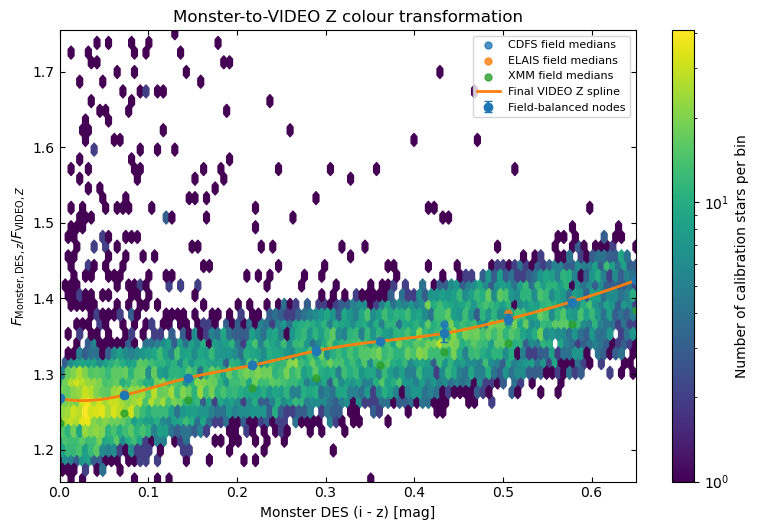

Saved: data/outputs/Monster_VIDEO_Z/video_z_final_colour_transformation.pdf


In [26]:
plot_mask = (
    np.isfinite(
        colour
    )
    & np.isfinite(
        ratio
    )
    & (
        colour
        >= FINAL_NODES[
            0
        ]
    )
    & (
        colour
        <= FINAL_NODES[
            -1
        ]
    )
)

ratio_plot_values = ratio[
    plot_mask
]

low_ratio, high_ratio = np.nanpercentile(
    ratio_plot_values,
    [
        0.5,
        99.5,
    ],
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5.4,
    )
)

hexbin = ax.hexbin(
    colour[
        plot_mask
    ],
    ratio[
        plot_mask
    ],
    gridsize=100,
    mincnt=1,
    bins="log",
)

for field in VIDEO_FILES:

    sub = final_field_node_table[
        final_field_node_table[
            "field"
        ]
        == field
    ]

    ax.scatter(
        sub[
            "node_colour"
        ],
        sub[
            "field_median_ratio"
        ],
        s=25,
        alpha=0.8,
        label=f"{field} field medians",
    )

ax.errorbar(
    final_node_table[
        "node_colour"
    ],
    final_node_table[
        "node_ratio"
    ],
    yerr=final_node_table[
        "node_uncertainty"
    ],
    fmt="o",
    capsize=3,
    label="Field-balanced nodes",
)

ax.plot(
    final_colour_grid,
    final_grid_ratio,
    linewidth=2,
    label="Final VIDEO Z spline",
)

ax.set_xlim(
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
)

pad = 0.05 * (
    high_ratio
    - low_ratio
)

ax.set_ylim(
    low_ratio
    - pad,
    high_ratio
    + pad,
)

ax.set_xlabel(
    "Monster DES (i - z) [mag]"
)

ax.set_ylabel(
    r"$F_{\mathrm{Monster,DES},z}/F_{\mathrm{VIDEO},Z}$"
)

ax.set_title(
    "Monster-to-VIDEO Z colour transformation"
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend(
    fontsize=8
)

colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of calibration stars per bin"
)

fig.tight_layout()

FINAL_TRANSFORMATION_PDF = (
    OUTPUT_DIR
    / "video_z_final_colour_transformation.pdf"
)

fig.savefig(
    FINAL_TRANSFORMATION_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {FINAL_TRANSFORMATION_PDF}"
)

### Direction test

The final relation is explicitly checked in the direction required by the downstream reference-catalogue construction:

$$
F_{\mathrm{VIDEO},Z}^{\mathrm{pred}}
=
\frac{F_{\mathrm{Monster,DES},z}}
     {R_Z(i-z)}.
$$

The fractional residual compares this predicted VIDEO flux with the observed VIDEO `APER_2` flux.

In [27]:
unique_colour = float_array(
    unique_z_calibration_sample[
        "monster_iz_colour"
    ]
)

unique_monster_z_flux = float_array(
    unique_z_calibration_sample[
        "monster_z_flux_njy"
    ]
)

unique_video_z_flux = float_array(
    unique_z_calibration_sample[
        "video_z_flux_njy"
    ]
)

model_ratio = evaluate_spline(
    final_z_spline,
    unique_colour,
    FINAL_NODES[
        0
    ],
    FINAL_NODES[
        -1
    ],
)

valid_direction = (
    np.isfinite(
        model_ratio
    )
    & (
        model_ratio
        > 0.0
    )
    & np.isfinite(
        unique_monster_z_flux
    )
    & (
        unique_monster_z_flux
        > 0.0
    )
    & np.isfinite(
        unique_video_z_flux
    )
    & (
        unique_video_z_flux
        > 0.0
    )
)

predicted_video_z_flux = (
    unique_monster_z_flux[
        valid_direction
    ]
    / model_ratio[
        valid_direction
    ]
)

fractional_flux_residual = (
    predicted_video_z_flux
    - unique_video_z_flux[
        valid_direction
    ]
) / unique_video_z_flux[
    valid_direction
]

delta_mag_direction = (
    -2.5
    * np.log10(
        predicted_video_z_flux
        / unique_video_z_flux[
            valid_direction
        ]
    )
)

print(
    f"Sources in direction test: "
    f"{np.count_nonzero(valid_direction):,}"
)

print(
    "Median fractional flux residual: "
    f"{100.0 * np.median(fractional_flux_residual):+.4f}%"
)

print(
    "Fractional flux residual NMAD: "
    f"{100.0 * robust_nmad(fractional_flux_residual):.4f}%"
)

print(
    "Median predicted-observed magnitude: "
    f"{np.median(delta_mag_direction):+.5f} mag"
)

print(
    "Magnitude NMAD: "
    f"{robust_nmad(delta_mag_direction):.5f} mag"
)

Sources in direction test: 11,067
Median fractional flux residual: -0.7058%
Fractional flux residual NMAD: 2.9467%
Median predicted-observed magnitude: +0.00769 mag
Magnitude NMAD: 0.03222 mag


### Optional comparison with the existing VIKING-derived Z transformation

If `Monster_to_VISTA_band_z.yaml` is present beside this notebook, the two relations are plotted together.

This comparison is diagnostic only. The VIDEO fit is not shifted or otherwise adjusted to agree with VIKING.

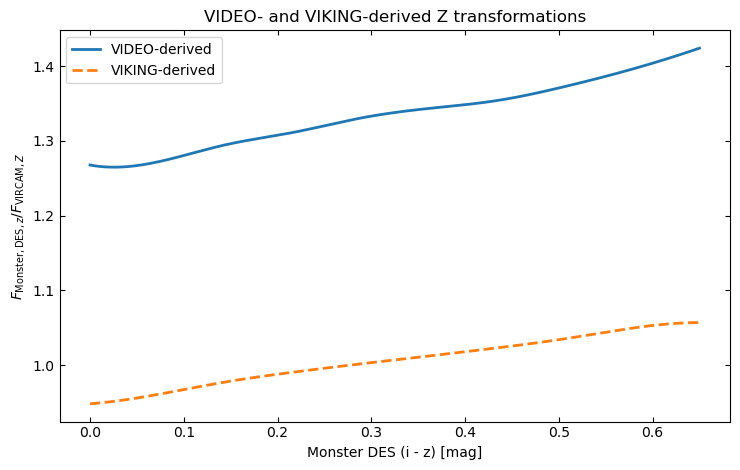

Median VIDEO-minus-VIKING ratio difference: +0.330272
Median implied VIDEO-target minus VIKING-target magnitude: +0.3060 mag


In [28]:
VIKING_YAML_PATH = Path(
    "Monster_to_VISTA_band_z.yaml"
)

if VIKING_YAML_PATH.exists():

    with VIKING_YAML_PATH.open(
        "r",
        encoding="utf-8",
    ) as stream:

        viking_yaml = yaml.safe_load(
            stream
        )

    viking_nodes = np.asarray(
        viking_yaml[
            "nodes"
        ],
        dtype=float,
    )

    viking_values = np.asarray(
        viking_yaml[
            "spline_values"
        ],
        dtype=float,
    )

    viking_spline = make_interp_spline(
        viking_nodes,
        viking_values,
        k=3,
    )

    common_min = max(
        FINAL_NODES[
            0
        ],
        viking_nodes[
            0
        ],
    )

    common_max = min(
        FINAL_NODES[
            -1
        ],
        viking_nodes[
            -1
        ],
    )

    common_colour = np.linspace(
        common_min,
        common_max,
        500,
    )

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            4.8,
        )
    )

    ax.plot(
        common_colour,
        final_z_spline(
            common_colour
        ),
        linewidth=2,
        label="VIDEO-derived",
    )

    ax.plot(
        common_colour,
        viking_spline(
            common_colour
        ),
        linewidth=2,
        linestyle="--",
        label="VIKING-derived",
    )

    ax.set_xlabel(
        "Monster DES (i - z) [mag]"
    )

    ax.set_ylabel(
        r"$F_{\mathrm{Monster,DES},z}/F_{\mathrm{VIRCAM},Z}$"
    )

    ax.set_title(
        "VIDEO- and VIKING-derived Z transformations"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

    ratio_difference = (
        final_z_spline(
            common_colour
        )
        - viking_spline(
            common_colour
        )
    )

    print(
        "Median VIDEO-minus-VIKING ratio difference: "
        f"{np.median(ratio_difference):+.6f}"
    )

    video_ratio_common = final_z_spline(
        common_colour
    )

    viking_ratio_common = viking_spline(
        common_colour
    )

    valid_comparison = (
        np.isfinite(
            video_ratio_common
        )
        & np.isfinite(
            viking_ratio_common
        )
        & (
            video_ratio_common > 0.0
        )
        & (
            viking_ratio_common > 0.0
        )
    )

    target_delta_mag = (
        -2.5
        * np.log10(
            (
                viking_ratio_common[
                    valid_comparison
                ]
                / video_ratio_common[
                    valid_comparison
                ]
            )
        )
    )

    print(
        "Median implied VIDEO-target minus VIKING-target magnitude: "
        f"{np.median(target_delta_mag):+.4f} mag"
    )

else:

    print(
        "Existing VIKING YAML not found; "
        "comparison skipped."
    )


### Write and verify `Monster_to_VIDEO_band_z.yaml`

The YAML uses the same minimal key structure as the existing Monster colour-term products.

`target_survey` remains `VISTA` because the target passband is VIRCAM Z. The filename records that the empirical calibration sample is VIDEO DR5.

The stored ratio is Monster/VIRCAM, so downstream reconstruction must use **division**.

In [29]:
if "validation_summary" not in globals() or len(validation_summary) != len(VIDEO_FILES):
    raise RuntimeError(
        "Final YAML will not be written because three-field leave-one-field-out "
        "validation did not complete successfully."
    )

FINAL_YAML_OUTPUT = (
    OUTPUT_DIR
    / "Monster_to_VIDEO_band_z.yaml"
)

FINAL_YAML_REPOSITORY = Path(
    "Monster_to_VIDEO_band_z.yaml"
)

yaml_contents = {
    "flux_offset":
        0.0,
    "nodes":
        [
            float(
                value
            )
            for value
            in final_node_table[
                "node_colour"
            ]
        ],
    "source_color_field_1":
        "monster_DES_i_flux",
    "source_color_field_2":
        "monster_DES_z_flux",
    "source_field":
        "monster_DES_z_flux",
    "source_survey":
        "Monster",
    "spline_values":
        [
            float(
                value
            )
            for value
            in final_node_table[
                "node_ratio"
            ]
        ],
    "target_survey":
        "VISTA",
}


for path in [
    FINAL_YAML_OUTPUT,
    FINAL_YAML_REPOSITORY,
]:

    with path.open(
        "w",
        encoding="utf-8",
    ) as stream:

        yaml.safe_dump(
            yaml_contents,
            stream,
            sort_keys=False,
            default_flow_style=False,
        )


with FINAL_YAML_OUTPUT.open(
    "r",
    encoding="utf-8",
) as stream:

    reloaded_yaml = yaml.safe_load(
        stream
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml[
            "nodes"
        ],
        dtype=float,
    ),
    FINAL_NODES,
):
    raise RuntimeError(
        "Reloaded VIDEO Z YAML nodes differ from final nodes."
    )


if not np.allclose(
    np.asarray(
        reloaded_yaml[
            "spline_values"
        ],
        dtype=float,
    ),
    final_node_table[
        "node_ratio"
    ].to_numpy(
        dtype=float
    ),
):
    raise RuntimeError(
        "Reloaded VIDEO Z YAML spline values differ from final fit."
    )


print(
    "Final VIDEO Z YAML written and verified:"
)

print(
    f"  {FINAL_YAML_OUTPUT}"
)

print(
    f"  {FINAL_YAML_REPOSITORY}"
)


Final VIDEO Z YAML written and verified:
  data/outputs/Monster_VIDEO_Z/Monster_to_VIDEO_band_z.yaml
  Monster_to_VIDEO_band_z.yaml


### Save final validation products

These tables preserve the information needed to reproduce and audit the final relation:

- effective matching epochs;
- field-balanced final nodes;
- field-specific node measurements;
- leave-one-field-out summary;
- leave-one-field-out source residuals.

In [30]:
EPOCH_TABLE_PATH = (
    OUTPUT_DIR
    / "video_z_effective_epochs.csv"
)

FINAL_NODE_PATH = (
    OUTPUT_DIR
    / "video_z_final_field_balanced_nodes.csv"
)

FIELD_NODE_PATH = (
    OUTPUT_DIR
    / "video_z_final_field_nodes.csv"
)

VALIDATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "video_z_leave_one_field_out_summary.csv"
)

VALIDATION_RESIDUAL_PATH = (
    OUTPUT_DIR
    / "video_z_leave_one_field_out_residuals.fits"
)

effective_epoch_table.to_csv(
    EPOCH_TABLE_PATH,
    index=False,
)

final_node_table.to_csv(
    FINAL_NODE_PATH,
    index=False,
)

final_field_node_table.to_csv(
    FIELD_NODE_PATH,
    index=False,
)

validation_summary.to_csv(
    VALIDATION_SUMMARY_PATH,
    index=False,
)

validation_residuals.write(
    VALIDATION_RESIDUAL_PATH,
    overwrite=True,
)

print("Saved final validation products:")
for path in [
    EPOCH_TABLE_PATH,
    FINAL_NODE_PATH,
    FIELD_NODE_PATH,
    VALIDATION_SUMMARY_PATH,
    VALIDATION_RESIDUAL_PATH,
]:
    print(
        f"  {path}"
    )

Saved final validation products:
  data/outputs/Monster_VIDEO_Z/video_z_effective_epochs.csv
  data/outputs/Monster_VIDEO_Z/video_z_final_field_balanced_nodes.csv
  data/outputs/Monster_VIDEO_Z/video_z_final_field_nodes.csv
  data/outputs/Monster_VIDEO_Z/video_z_leave_one_field_out_summary.csv
  data/outputs/Monster_VIDEO_Z/video_z_leave_one_field_out_residuals.fits
